# 🤖 Project Budget & Duration Predictor
Predicts **final_budget_usd** and **duration_days** from project features.

Prices are normalized to **USD** (via the daily `usd_rate`) instead of raw IRR,
since IRR has been too unstable over this dataset's ~15-year span to be a
meaningful regression target on its own.

Sections:
1. Load & inspect
2. Target engineering (USD normalization, null handling, log transform)
3. Feature engineering & encoding
4. EDA — distributions, correlations
5. Train models — classical ML (GradientBoosting, Random Forest, XGBoost)
6. Train a deep learning model (feed-forward neural net)
7. Classical vs Deep Learning comparison
8. Feature importance (classical models)
9. SHAP — per-prediction explanations
10. Error analysis
11. Cross-validation
12. Inference helper

In [1]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
warnings.filterwarnings('ignore')
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
ACCENT, ACCENT2 = '#5B8DEF', '#F4845F'

# ── Paths ────────────────────────────────────────────────────────────────
CSV_PATH = Path('../ml_dataset/full_dataset.csv')   # <-- adjust if needed
# CSV_PATH = Path('/absolute/path/to/full_dataset.csv')

BUDGET_RATIO_THRESHOLD = 3.0  # max/min ratio to accept imputed budget (avg of min/max)

# Only rows with a resolvable USD exchange rate can have a USD target.
# (build_dataset.py already computes this from the nearest available
# daily rate, average of open/high/low/close, keyed off scraped_date_created.)
REQUIRE_USD_RATE = True

ENUM_COLS = [
    'project_type', 'ai_level', 'business_logic', 'data_volume',
    'integration_complexity', 'ui_complexity', 'algorithmic_complexity'
]
# Columns that are not model inputs
NON_FEATURE = [
    'project_id','title','category','organization','created_at','scraped_date_created',
    'final_budget','log_final_budget','budget_min','budget_max','log_budget_min','log_budget_max',
    'budget_range','budget_range_ratio','has_final_budget','duration',
    'description','skills','outer_link','updated_at','category_scraped_id','description_length',
     'description_word_count', 'skill_count',
      'external_api_count','estimated_screens','estimated_entities',
    #   'requires_refactoring','requires_reverse_engineering','cross_platform',
    'ai_level','business_logic','data_volume','integration_complexity','ui_complexity','algorithmic_complexity',
    'feature_score_sum','feature_count','feature_score_mean','feature_score_max'

    # USD normalization columns (rate + amounts) — inputs to target engineering,
    # not model features themselves
    'usd_rate','usd_rate_date','final_budget_usd','log_final_budget_usd',
    'budget_min_usd','budget_max_usd','log_budget_min_usd','log_budget_max_usd',
    'budget_range_usd',
    # derived targets added later
    'target_budget','is_budget_imputed','is_days_null',
    'log_target_budget',
]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df_raw = pd.read_csv(CSV_PATH)
print(f'✅  {len(df_raw):,} rows  ·  {df_raw.shape[1]} columns')
print(f'    Organizations: {df_raw.organization.unique()}')

if REQUIRE_USD_RATE and 'usd_rate' in df_raw.columns:
    n_no_rate = df_raw['usd_rate'].isna().sum()
    print(f'    Rows with no usable USD rate (dropped before modeling): '
          f'{n_no_rate:,} ({n_no_rate/len(df_raw):.1%})')

df_raw.head(2)

d:\PROGRAMMING\Web\Final Project\KarChandV2\backend\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅  19,668 rows  ·  164 columns
    Organizations: <StringArray>
['Karlancer', 'Ponisha']
Length: 2, dtype: str
    Rows with no usable USD rate (dropped before modeling): 0 (0.0%)


,project_id,title,category,organization,created_at,scraped_date_created,usd_rate,usd_rate_date,final_budget,log_final_budget,final_budget_usd,log_final_budget_usd,budget_min,budget_max,log_budget_min,log_budget_max,budget_min_usd,budget_max_usd,log_budget_min_usd,log_budget_max_usd,budget_range_usd,budget_range_ratio,has_final_budget,duration,duration_days,description_length,description_word_count,skill_count,skills,description,outer_link,Authentication,Authorization & Role Management,User Management,User Profiles,Infrastructure & Operations,Administration Panel,Dashboard,Settings & Configuration,Content Management,Rich Text Editing,Media Management,Forms & Data Collection,File Upload & Storage,Document Management,Search,Filtering & Sorting,Import & Export,Reporting,Analytics,Data Processing,Data Migration,Notifications,Messaging & Chat,Email Services,SMS Services,Video & Voice Communication,Scheduling & Calendar,Workflow Automation,Task Management,Approval Workflow,Payment Processing,Wallet & Balance Management,Shopping Cart & Checkout,Order Management,Inventory Management,Product Catalog,Pricing & Discount Rules,Marketplace,Booking & Reservation,Subscription Management,External API Integration,Payment Gateway Integration,Social Authentication,Map & Geolocation Integration,Hardware Integration,Image Processing,Video Processing,Audio Processing,Streaming,Document Processing,Artificial Intelligence Integration,Recommendation & Personalization,Machine Learning Pipeline,Real-time Updates,Background Jobs,Caching,Offline Support,Data Synchronization,Multi-tenancy,Plugin / Extension System,Localization & Internationalization,Accessibility,Responsive Design,SEO,Security,Audit Logs,Monitoring & Logging,Backup & Recovery,Mobile Application,Web Application,Desktop Application,Browser Extension,Social Features,Comments & Reviews,Gamification,Visualization & Charts,Maps & Spatial Analysis,Scientific & Mathematical Computation,Optimization & Simulation,Web Scraping & Crawling,Bots & Automation,Code Generation & Development Tools,website,web_application,mobile_application,desktop_application,api_backend,ecommerce,marketplace,cms,crm,erp,lms,booking_system,social_network,media_platform,financial_system,healthcare_system,real_estate_platform,automation_system,iot_system,ai_application,browser_extension,other,WordPress,WooCommerce,Joomla,Custom Development,external_api_count,estimated_screens,estimated_entities,real_time,mobile,web,offline,legacy_system,existing_codebase,requires_refactoring,requires_reverse_engineering,cross_platform,project_type,ai_level,business_logic,data_volume,integration_complexity,ui_complexity,algorithmic_complexity,updated_at,category_scraped_id,feature_score_sum,feature_count,feature_score_mean,feature_score_max
0,a6ae2518-7cb9-4915-8629-13090f989342,ساخت بات فروشگاهی تلگرام,پروژه‌های برنامه نویسی,Karlancer,2026-06-25T08:48:44.751434,2026-06-11 05:03:00,179565.00,2026-06-11,500000.0,13.122365,2.784507,1.330916,100000.0,3000000.0,11.512935,14.914123,0.556901,16.707042,0.442698,2.873962,16.150141,30.000000,True,1.0,1.0,129,23,8,python | برنامه نویسی | برنامه نویسی وب | ربات | ساخت ربات | ساخت ربات تلگرام | طراحی ربات | کدنویسی,بات فروشگاهی بدون درگاه پرداخت\nبرای فروش اکانت\nباپنل مدیریت وویرایش کامل محصولات و قیمتها\nپشتیبانی و آموزش کار با بات برای مدیریت,ساخت-بات-فروشگاهی-تلگرام-1n69eo32262o,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,4,3,1,0,1,0,0,0,0,0,0,new,none,medium,small,low,low,low,2026-06-25 08:48:44.751434,6,11,3,0.134146,4
1,2e8ba95c-7051-4099-9e4f-02c85b549ae5,ساخت ربات تلگرام,پروژه‌های برنامه نویسی,Karlancer,2026-06-25T08:48:46.121224,2026-06-02 09:39:53,174628.75,2026-06-02,1500000.0,14.220976,8.589651,2.260684,1500000.0,3500000.0,14.220976,15.068274,8.589651,20.042519,2.260684,3.046545,11.452868,2.333333,True,7.0,7.0,280,55,8,pyt

## 1 · Target engineering
**USD normalization:** every budget figure is converted from IRR to USD using
`usd_rate` (nearest available daily rate) *before* any null-handling. Rows with
no resolvable `usd_rate` are dropped — we can't meaningfully price a project
without knowing what its IRR figure was worth at the time.

**Budget null rule:** if `final_budget_usd` is null and `budget_max_usd / budget_min_usd ≤ threshold` → use average of min/max. Otherwise drop the row.

**Duration null rule:** fill with dataset median, add `is_days_null` flag so the model knows the value was imputed.

Rows dropped (no USD rate): 0
Rows before: 19,668  |  dropped (ratio too high): 3070  |  kept: 16,598
Budget imputed (avg min/max): 3773
Duration filled with median (7 days): 6797



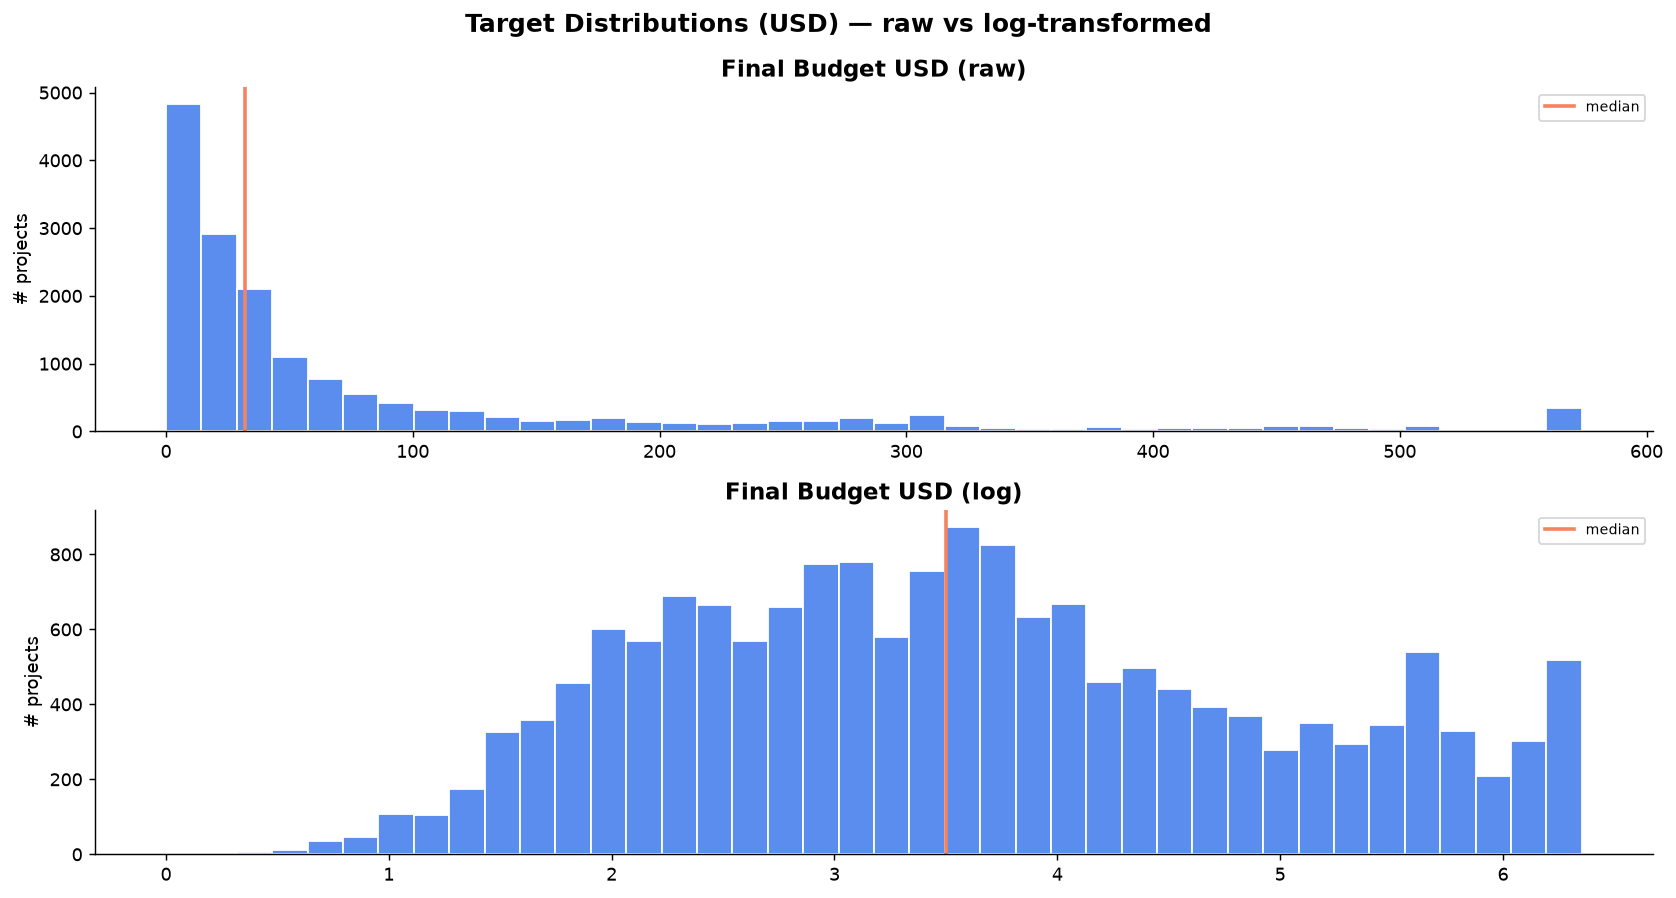

In [83]:
# Drop rows with no usable USD rate first — everything downstream is USD-denominated.
df = df_raw[df_raw['usd_rate'].notna()].copy() if REQUIRE_USD_RATE else df_raw.copy()
n_dropped_no_rate = len(df_raw) - len(df)
PCT_THRESHOLD = 0.10
# ── Budget (USD) ─────────────────────────────────────────────────────────
def resolve_final_budget(row):

    if pd.notna(row['final_budget_usd']) and row["final_budget_usd"] != 0 and not row['final_budget_usd'] < row['budget_min_usd'] * (1 - PCT_THRESHOLD):
        return row['final_budget_usd'], False   # (value, is_imputed)
    ratio = row['budget_max_usd'] / max(row['budget_min_usd'], 1e-6)
    if ratio <= BUDGET_RATIO_THRESHOLD:
        return (row['budget_min_usd'] + row['budget_max_usd']) / 2, True
    return np.nan, False   # ratio too high → will be dropped

df[['target_budget', 'is_budget_imputed']] = df.apply(
    lambda r: pd.Series(resolve_final_budget(r)), axis=1
)
before = len(df)
df = df[df['target_budget'].notna()].copy()
dropped = before - len(df)

# ── Duration ─────────────────────────────────────────────────────────────
duration_median = df['duration_days'].median()
df['is_days_null'] = df['duration_days'].isna().astype(int)
df['duration_days'] = df['duration_days'].fillna(duration_median)

# ── Log-transform targets (right-skewed money/time values) ────────────────
df['log_target_budget']   = np.log1p(df['target_budget'])

print(f'Rows dropped (no USD rate): {n_dropped_no_rate:,}')
print(f'Rows before: {before:,}  |  dropped (ratio too high): {dropped}  |  kept: {len(df):,}')
print(f'Budget imputed (avg min/max): {df.is_budget_imputed.sum()}')
print(f'Duration filled with median ({duration_median:.0f} days): {df.is_days_null.sum()}')
print()

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, col, label in [
    (axes[0], 'target_budget',       'Final Budget USD (raw)'),
    (axes[1], 'log_target_budget',   'Final Budget USD (log)'),
]:
    ax.hist(df[col].clip(upper=df[col].quantile(0.98)), bins=40, color=ACCENT, edgecolor='white')
    ax.axvline(df[col].median(), color=ACCENT2, linewidth=2, label='median')
    ax.set_title(label); ax.set_ylabel('# projects'); ax.legend(fontsize=8)
fig.suptitle('Target Distributions (USD) — raw vs log-transformed', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 2 · Feature engineering & encoding

In [84]:
# Ordinal encode enums (low=0, medium=1, high=2 etc.)
ENUM_ORDER = {
    'project_type':           ['new','maintenance','migration','bugfix','optimization','testing','consulting'],
    'ai_level':               ['none','basic','advanced'],
    'business_logic':         ['low','medium','high'],
    'data_volume':            ['small','medium','large'],
    'integration_complexity': ['low','medium','high'],
    'ui_complexity':          ['low','medium','high'],
    'algorithmic_complexity': ['low','medium','high'],
}

print('=== Enum value before ===')
for col in ENUM_COLS:
    print(col)
    print(df[col].value_counts(dropna=False).head(20))
    print()

enc = OrdinalEncoder(categories=[ENUM_ORDER[c] for c in ENUM_COLS], handle_unknown='use_encoded_value', unknown_value=-1)
df[ENUM_COLS] = df[ENUM_COLS].astype(str).apply(lambda s: s.str.strip().str.lower())
df[ENUM_COLS] = enc.fit_transform(df[ENUM_COLS])

# Final feature list: everything not in NON_FEATURE and not object dtype
ALL_FEATURES = [
    c for c in df.columns
    if c not in NON_FEATURE and df[c].dtype != object
]
# print(f'Model input features: {len(ALL_FEATURES)}')
# print('Sample:', ALL_FEATURES[:10], '...')

X  = df[ALL_FEATURES]
yB = df['log_target_budget']


X_tr, X_te, yB_tr, yB_te = train_test_split(
    X, yB, test_size=0.3, random_state=42
)
# print(f'Train: {len(X_tr):,}  |  Test: {len(X_te):,}')
print('-------------------')
print(X_tr.head(2))
print('=========')
print(yB_tr.head(2))

=== Enum value before ===
project_type
project_type
new             9457
maintenance     3886
bugfix          1732
optimization     668
migration        446
consulting       390
testing           19
Name: count, dtype: int64

ai_level
ai_level
none        15558
advanced      675
basic         365
Name: count, dtype: int64

business_logic
business_logic
low       9636
medium    5542
high      1420
Name: count, dtype: int64

data_volume
data_volume
small     12178
medium     3978
large       442
Name: count, dtype: int64

integration_complexity
integration_complexity
low       13166
medium     2896
high        536
Name: count, dtype: int64

ui_complexity
ui_complexity
low       10529
medium     5226
high        843
Name: count, dtype: int64

algorithmic_complexity
algorithmic_complexity
low       13010
medium     2546
high       1042
Name: count, dtype: int64

-------------------
       usd_rate  duration_days  Authentication  \
11103  82247.50            3.0               4   
12174  50

## 3 · EDA — target vs key features

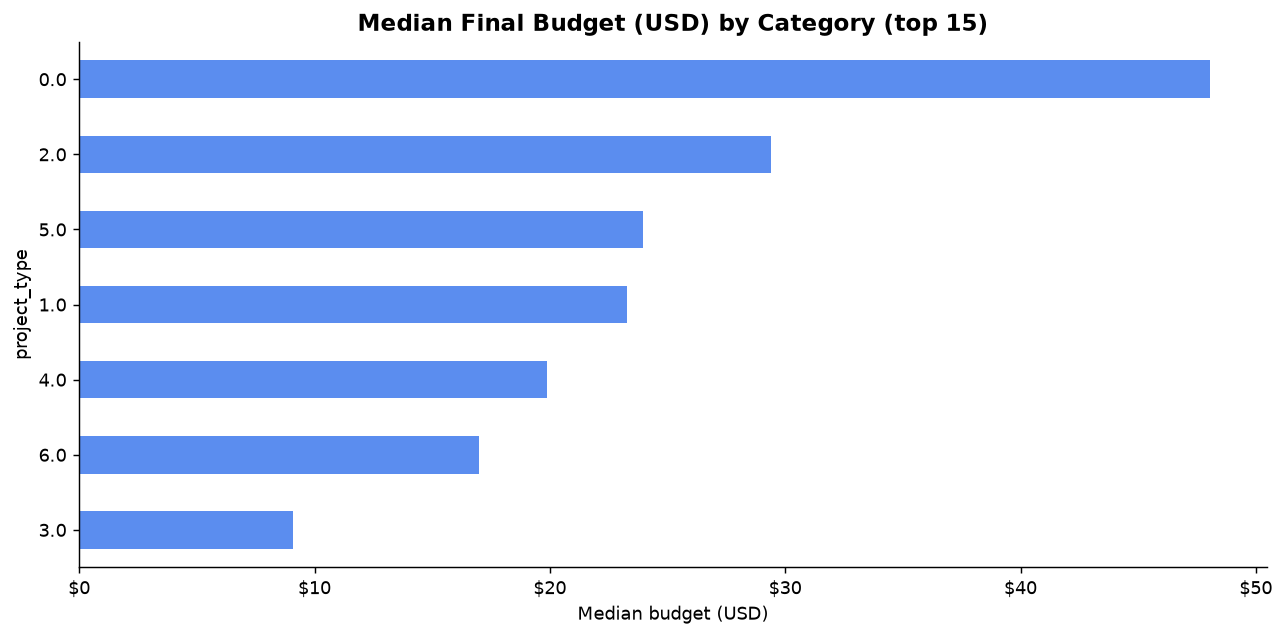

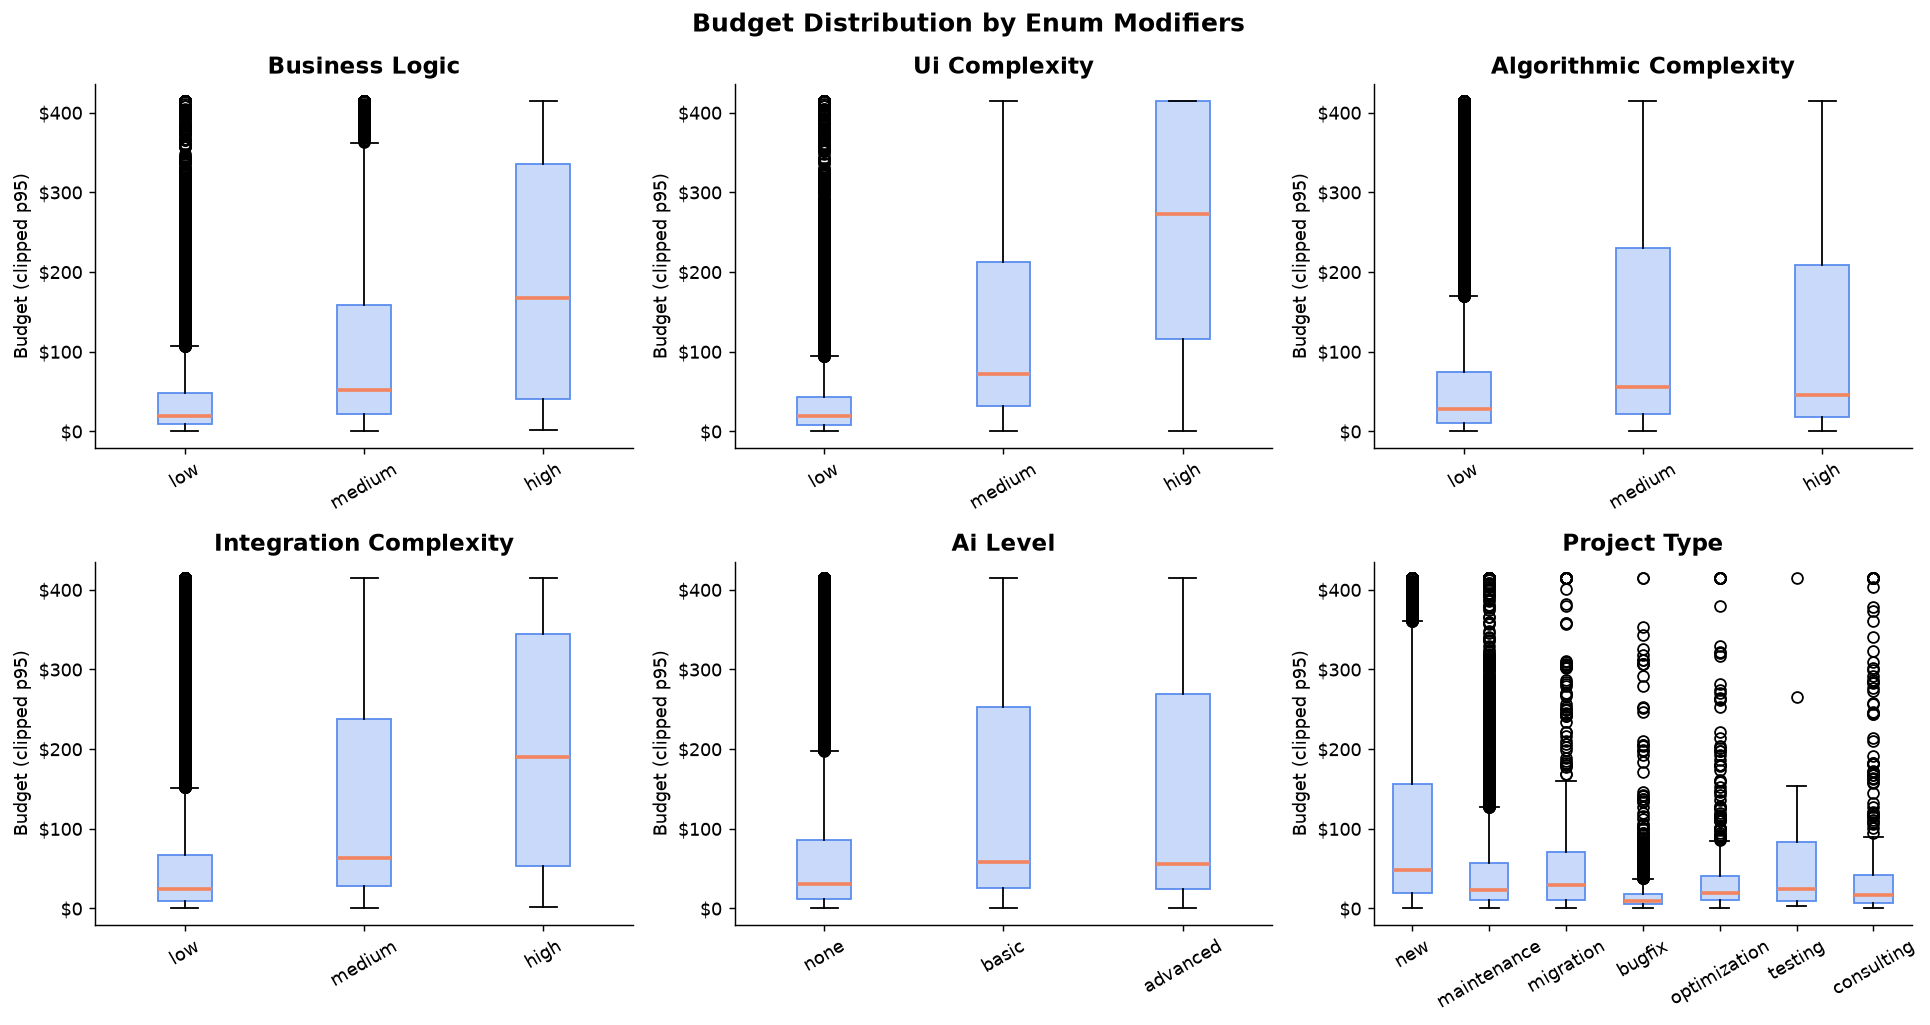

In [85]:
# Budget by category (top 15 by median)
cat_budget = (df.groupby('project_type')['target_budget']
                .median().sort_values(ascending=False).head(15))
fig, ax = plt.subplots(figsize=(10, 5))
cat_budget.plot(kind='barh', ax=ax, color=ACCENT)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Median Final Budget (USD) by Category (top 15)')
ax.set_xlabel('Median budget (USD)')
plt.tight_layout(); plt.show()

# Budget vs complexity enums
raw_enum_cols = ['business_logic','ui_complexity','algorithmic_complexity','integration_complexity','ai_level','project_type']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), raw_enum_cols):
    order = ENUM_ORDER.get(col, sorted(df_raw[col].dropna().unique()))
    present = [v for v in order if v in df_raw[col].values]
    data = [df.loc[df_raw.loc[df.index, col] == v, 'target_budget'].clip(upper=df['target_budget'].quantile(0.95))
            for v in present]
    ax.boxplot(data, tick_labels=present, patch_artist=True,
               boxprops=dict(facecolor=ACCENT+'55', color=ACCENT),
               medianprops=dict(color=ACCENT2, linewidth=2))
    ax.set_title(col.replace('_',' ').title())
    ax.set_ylabel('Budget (clipped p95)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Budget Distribution by Enum Modifiers', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()




## Weights

In [72]:
print(X_tr.isna().sum().sort_values(ascending=False))

usd_rate                           0
duration_days                      0
Authentication                     0
Authorization & Role Management    0
User Management                    0
                                  ..
requires_refactoring               0
requires_reverse_engineering       0
cross_platform                     0
project_type                       0
feature_score_max                  0
Length: 121, dtype: int64


## 4 · Train models — Budget prediction

In [86]:
MODELS_BUDGET = {
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42),
    'RandomForest':     RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost':          xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                                         colsample_bytree=0.8, random_state=42, verbosity=0),
}

def choose_weighting_method(method:int):
    #1: Log-budget weights 
    #2: Square-root weights 
    #3: Frequency-based weighting

    match method:
        case 1:
            budget_train = np.expm1(yB_tr)

            weights = np.log1p(budget_train)
            weights /= weights.mean()

            return weights
        
        case 2:
            budget_train = np.expm1(yB_tr)

            weights = np.sqrt(budget_train)
            weights /= weights.mean()

            return weights
        
        case 3:
            budget = np.expm1(yB_tr)

            bins = pd.qcut(budget, q=10, duplicates='drop')
            freq = bins.value_counts()

            weights = bins.map(lambda b: 1 / freq[b])
            weights /= weights.mean()

            return weights
        
        case _: print("err in choosing weight")




def threshold_metrics(y_true_log, y_pred_log, thresholds=(0.1, 0.2, 0.3, 0.5)):
    """
    Evaluate predictions within percentage thresholds.

    thresholds:
        0.10 = ±10%
        0.20 = ±20%
        ...
    """

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    relative_error = np.abs(y_pred - y_true) / np.maximum(y_true, 1e-8)

    metrics = {}

    metrics["Median Relative Error"] = np.median(relative_error)
    metrics["Mean Relative Error"] = np.mean(relative_error)

    for t in thresholds:
        metrics[f"Within ±{int(t*100)}%"] = np.mean(relative_error <= t)

    return metrics

def interval_accuracy(y_true_log, y_pred_log, pct=0.20):

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    lower = y_pred * (1 - pct)
    upper = y_pred * (1 + pct)

    inside = (y_true >= lower) & (y_true <= upper)

    return inside.mean()


def evaluate(model, X_tr, y_tr, X_te, y_te, name='', sample_weight=None):
    if sample_weight is None:
        model.fit(X_tr, y_tr)
    else:
        model.fit(X_tr, y_tr, sample_weight=sample_weight)

    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    true_budget = np.expm1(y_te)
    pred_budget = np.expm1(pred_te)

    mae_te = mean_absolute_error(true_budget, pred_budget)

    extra_metrics = threshold_metrics(y_te, pred_te)
    r2_tr   = r2_score(y_tr, pred_tr)
    r2_te   = r2_score(y_te, pred_te)
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(
        f'  {name:<20}  R² train={r2_tr:.3f}  '
        f'R² test={r2_te:.3f}  '
        f'RMSE(log)={rmse_te:.3f}  '
        f'MAE={mae_te:>12,.0f}'
    )

    print(
    f"      Median Relative Error : {extra_metrics['Median Relative Error']:.2%}"
    )

    print(
        f"      Mean Relative Error   : {extra_metrics['Mean Relative Error']:.2%}"
    )

    print(f"      Coverage ±10% : {cov10:.2%}")
    print(f"      Coverage ±20% : {cov20:.2%}")
    print(f"      Coverage ±30% : {cov30:.2%}")
    print(f"      Coverage ±50% : {cov50:.2%}")

    true_budget = pd.Series(np.expm1(yB_te))
    pred_budget = pd.Series(np.expm1(best_budget["pred_test"]))

    print(true_budget.describe())
    print(pred_budget.describe())

    for k, v in extra_metrics.items():
        if "Within" in k:
            print(f"      {k:<15}: {v:.2%}")

    return {
        'model': model,
        'name': name,
        'r2_test': r2_te,
        'mae_test': mae_te,
        'pred_test': pred_te,
        'r2_train': r2_tr,
    }
print('=== Budget models (predicting log_target_budget) ===')
budget_results = {}

print(choose_weighting_method(1))
sample_weights=choose_weighting_method(1)

for name, model in MODELS_BUDGET.items():
    res = evaluate(
        model,
        X_tr,
        yB_tr,
        X_te,
        yB_te,
        name,
        sample_weight=sample_weights

    )
    budget_results[name] = res

best_budget_name = max(budget_results, key=lambda k: budget_results[k]['r2_test'])
best_budget = budget_results[best_budget_name]
print(f'\n🏆 Best budget model: {best_budget_name}  (R²={best_budget["r2_test"]:.3f})')

=== Budget models (predicting log_target_budget) ===
11103    0.895301
12174    0.633386
1432     0.639549
15164    1.276886
9544     1.001932
           ...   
14187    1.596454
14879    0.862473
6442     0.823687
860      1.327861
18836    1.423110
Name: log_target_budget, Length: 11618, dtype: float64
  GradientBoosting      R² train=0.588  R² test=0.533  RMSE(log)=0.952  MAE=          66
      Median Relative Error : 59.64%
      Mean Relative Error   : 666822210.82%
      Coverage ±10% : 9.32%
      Coverage ±20% : 17.99%
      Coverage ±30% : 26.14%
      Coverage ±50% : 44.72%
count    4980.000000
mean      103.042792
std       262.029559
min         0.000000
25%        11.376686
50%        31.714666
75%        91.716988
max      8882.177910
Name: log_target_budget, dtype: float64
count    5005.000000
mean       76.507849
std        98.939504
min         6.135230
25%        22.231404
50%        37.822303
75%        77.511707
max      1052.048438
dtype: float64
      Within ±10% 

## 5b · Deep learning approach (feed-forward neural net)
Same features, same log-transformed targets — but a small dense neural network instead of trees. Neural nets need scaled inputs (trees don't), so we standardize features first.

In [74]:
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)
print(X_te.shape)

def build_mlp(input_dim, name, weight_decay=5e-5, learning_rate=1e-4):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        # layers.Dense(512, activation='relu'),
        # layers.BatchNormalization(),
        # layers.Dense(256, activation='relu'),
        # layers.BatchNormalization(),
        # layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ], name=name)
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
        loss=keras.losses.Huber(delta=1.0),
        metrics=['mae'],
    )
    return model

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

def evaluate_dl(X_tr_s, y_tr, X_te_s, y_te, name, epochs=300, batch_size=64):
    model = build_mlp(X_tr_s.shape[1], name)
    history = model.fit(
        X_tr_s, y_tr, validation_split=0.15,
        epochs=epochs, batch_size=batch_size,
        callbacks=[early_stop, reduce_lr], verbose=0,
    )
    pred_tr = model.predict(X_tr_s, verbose=0).flatten()
    pred_te = model.predict(X_te_s, verbose=0).flatten()
    mae_te  = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    r2_tr   = r2_score(y_tr, pred_tr)
    r2_te   = r2_score(y_te, pred_te)
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    n_epochs = len(history.history['loss'])
    print(f'  {name:<20}  R² train={r2_tr:.3f}  R² test={r2_te:.3f}  '
          f'RMSE(log)={rmse_te:.3f}  MAE={mae_te:>12,.0f}  (stopped after {n_epochs} epochs)')

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(f"      Coverage ±10% : {cov10:.2%}")
    print(f"      Coverage ±20% : {cov20:.2%}")
    print(f"      Coverage ±30% : {cov30:.2%}")
    print(f"      Coverage ±50% : {cov50:.2%}")

    return {'model': model, 'name': name, 'r2_test': r2_te, 'mae_test': mae_te,
            'pred_test': pred_te, 'r2_train': r2_tr, 'history': history}

print('=== Deep learning — budget model ===')
dl_budget = evaluate_dl(X_tr_scaled, yB_tr, X_te_scaled, yB_te, 'DeepLearning_MLP')

(5005, 121)
=== Deep learning — budget model ===


KeyboardInterrupt: 

In [87]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

# ============================================================
# Scale features
# ============================================================
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

print(X_tr_scaled.shape)
print(X_te_scaled.shape)

# ============================================================
# Build model
# ============================================================
def build_mlp(input_dim, name):
    l2 = regularizers.l2(1e-5)  # mild — drop this first if train R² stays low

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(256, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        layers.Dense(128, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.15),

        layers.Dense(64, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.10),

        layers.Dense(32, activation="gelu", kernel_regularizer=l2),
        layers.Dense(1),
    ], name=name)

    optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.Huber(delta=1.0),  # keep 1.0 for now; try 0.5 as a separate run if outliers are a known issue
        metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model

# ============================================================
# Callbacks
# ============================================================
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True,
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=1,
)

# ============================================================
# Train + Evaluate
# ============================================================
def evaluate_dl(X_tr_s, y_tr, X_te_s, y_te, name, epochs=300, batch_size=64):
    model = build_mlp(X_tr_s.shape[1], name)

    history = model.fit(
        X_tr_s, y_tr,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=1,          # <-- per-epoch progress bar
        shuffle=True,
    )

    pred_tr = model.predict(X_tr_s, verbose=0).flatten()
    pred_te = model.predict(X_te_s, verbose=0).flatten()

    mae_te  = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    r2_tr   = r2_score(y_tr, pred_tr)
    r2_te   = r2_score(y_te, pred_te)
    n_epochs = len(history.history["loss"])

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Training epochs : {n_epochs}")
    print(f"Train R²        : {r2_tr:.4f}")
    print(f"Test  R²        : {r2_te:.4f}")
    print(f"RMSE (log)      : {rmse_te:.4f}")
    print(f"MAE             : {mae_te:,.0f}")

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(f"Coverage ±10% : {cov10:.2%}")
    print(f"Coverage ±20% : {cov20:.2%}")
    print(f"Coverage ±30% : {cov30:.2%}")
    print(f"Coverage ±50% : {cov50:.2%}")

    return {
        "model": model, "history": history, "pred_test": pred_te,
        "r2_train": r2_tr, "r2_test": r2_te, "mae_test": mae_te,
    }

# ============================================================
# Train
# ============================================================
print("=== Deep Learning Budget Model ===")

dl_budget = evaluate_dl(
    X_tr_scaled, yB_tr, X_te_scaled, yB_te, "MLP_AdamW_Huber",
)

(11618, 121)
(4980, 121)
=== Deep Learning Budget Model ===
Epoch 1/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.8484 - mae: 2.2959 - rmse: 2.8762 - val_loss: 0.9669 - val_mae: 1.3851 - val_rmse: 1.7605 - learning_rate: 3.0000e-04
Epoch 2/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7945 - mae: 1.2017 - rmse: 1.5387 - val_loss: 0.5940 - val_mae: 0.9816 - val_rmse: 1.2576 - learning_rate: 3.0000e-04
Epoch 3/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6401 - mae: 1.0323 - rmse: 1.3214 - val_loss: 0.5289 - val_mae: 0.9117 - val_rmse: 1.1595 - learning_rate: 3.0000e-04
Epoch 4/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5885 - mae: 0.9769 - rmse: 1.2436 - val_loss: 0.5011 - val_mae: 0.8791 - val_rmse: 1.1202 - learning_rate: 3.0000e-04
Epoch 5/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5437 - mae: 0.9243 - rmse: 1.1838 - val_loss: 0.4825 - val_mae: 0.8593 - val_rmse: 1.0924 - learning_rate: 3.0000e-04
Epoch 6/300
155/155 ━━━━━━━━━━━━━━━

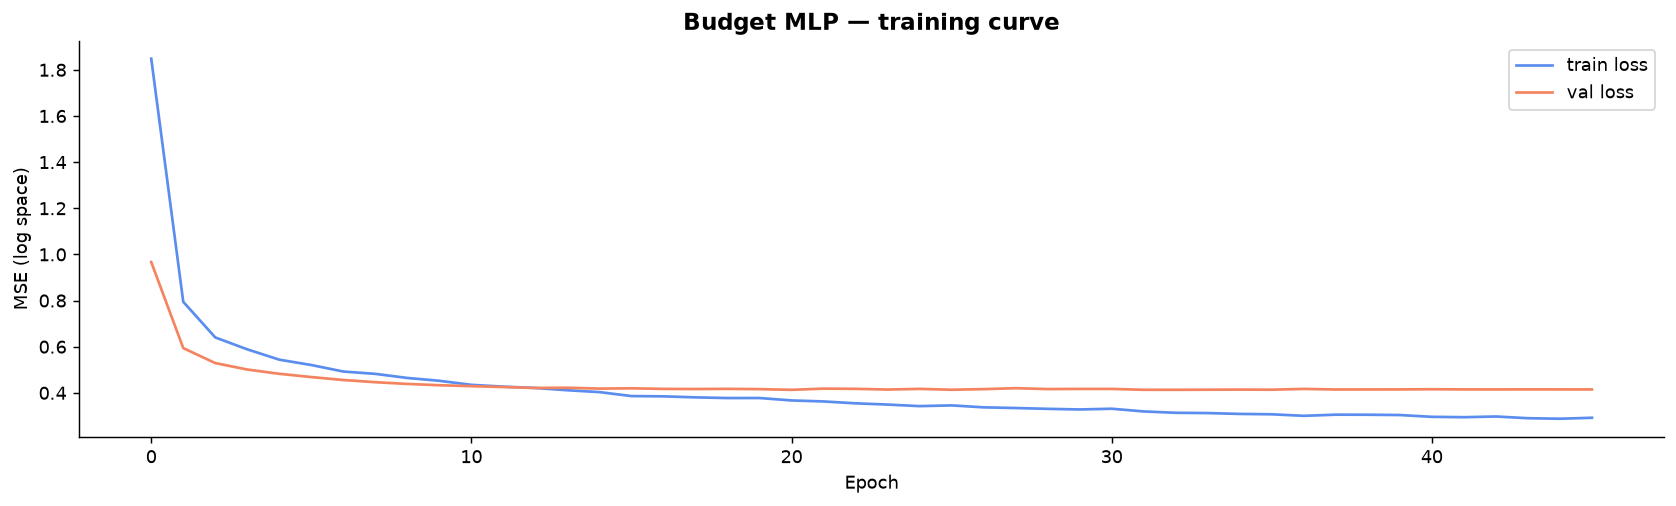

In [88]:
# Training curves — loss over epochs, useful for spotting over/underfitting
fig, axes = plt.subplots(1, 1, figsize=(13, 4))
for ax, res, title in [
    (axes, dl_budget,   'Budget MLP — training curve'),
]:
    h = res['history'].history
    ax.plot(h['loss'], label='train loss', color=ACCENT)
    ax.plot(h['val_loss'], label='val loss', color=ACCENT2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (log space)')
    ax.legend()
plt.tight_layout(); plt.show()


=== Worst 15 predictions (highest % error) ===
                                 project_id  actual     predicted  abs_error  pct_error
5452   62f0fa4f-64b7-447a-a254-f616bd72df34    0.00    255.699997     255.70        inf
2099   8a5033f0-d536-4ffd-8577-054e82361dbe    0.98    218.309998     217.34   22271.70
2715   ba67ee96-5893-4941-bfd9-c4ef1109775e    1.23    149.449997     148.23   12096.55
2701   1178c645-8a04-49c0-a87e-50fa13421c05    1.41    130.050003     128.64    9123.85
3423   c50981db-5fbe-442b-b43d-ff7384035085    1.73    125.900002     124.17    7182.06
5707   a91240ef-e1a9-48ec-b6d8-0f2c1b9b470d  127.54   9265.250000    9137.71    7164.68
247    48be2b80-50cc-4e44-86ed-9b092ce437a0   29.20   2015.329956    1986.13    6802.21
2704   919f33d1-6941-4d8a-a944-f8a444c42bb1    1.26     82.849998      81.59    6500.80
11470  4cfcb60b-d50c-4844-83c2-9a2e6baa4278  414.60  27234.439453   26819.85    6468.88
2697   23ef7877-8a63-42c6-9a32-adf79a88c7ed    0.79     42.959999      42

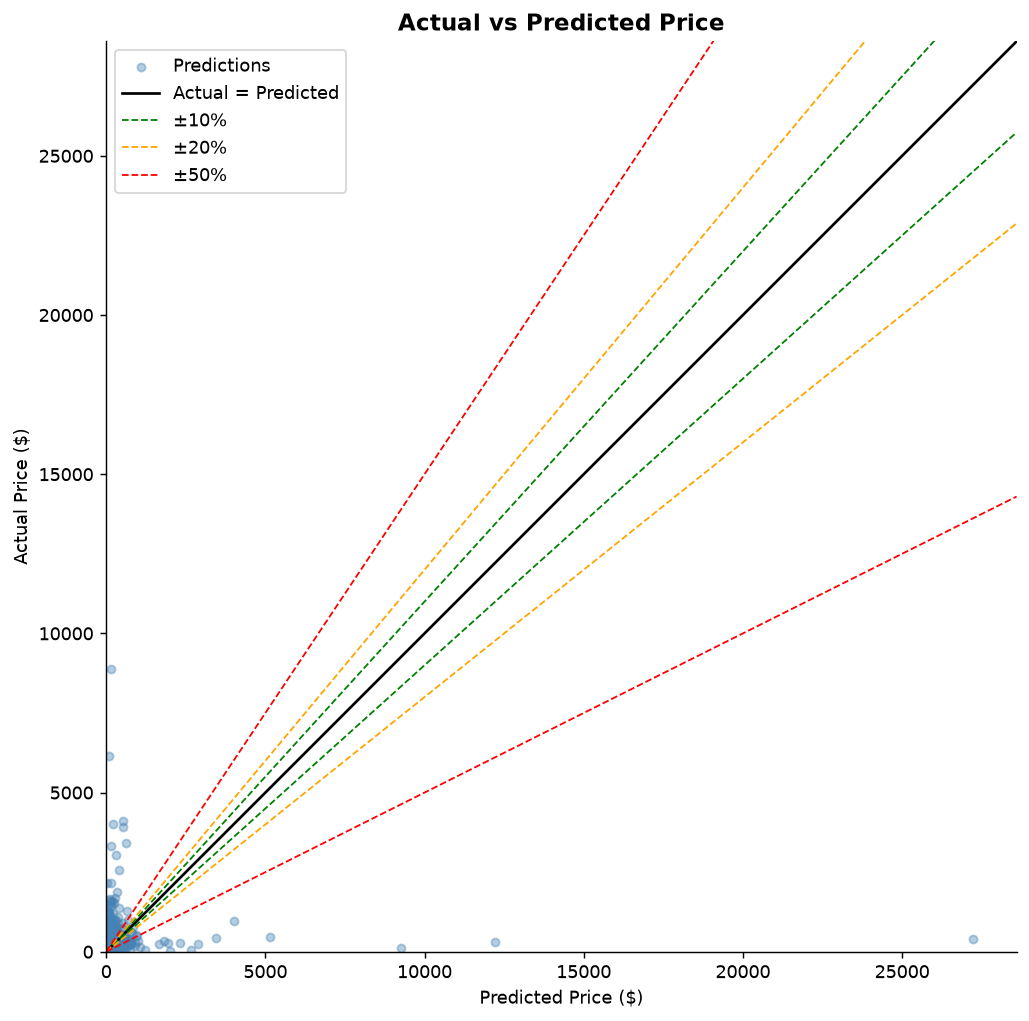

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Actual vs Predicted comparison table
# ============================================================

actual_usd    = np.expm1(yB_te)
predicted_usd = np.expm1(dl_budget['pred_test'])

comparison = pd.DataFrame({
    'project_id': df.loc[X_te.index, 'project_id'].values,   # adjust `df` to whatever your source frame is named
    'actual': actual_usd,
    'predicted': predicted_usd,
}, index=X_te.index)

comparison['abs_error']   = (comparison['actual'] - comparison['predicted']).abs()
comparison['pct_error']   = comparison['abs_error'] / comparison['actual'] * 100

comparison_sorted_worst = comparison.sort_values('pct_error', ascending=False)
comparison_sorted_best  = comparison.sort_values('pct_error', ascending=True)

print("=== Worst 15 predictions (highest % error) ===")
print(comparison_sorted_worst.head(15).round(2).to_string())

print()
print("=== Best 15 predictions (lowest % error) ===")
print(comparison_sorted_best.head(15).round(2).to_string())

print()
print(f"Median % error : {comparison['pct_error'].median():.2f}%")
print(f"Mean % error   : {comparison['pct_error'].mean():.2f}%")

# ============================================================
# Actual vs Predicted scatter chart with error-band lines
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(comparison['predicted'], comparison['actual'],
           alpha=0.4, s=20, color='steelblue', label='Predictions')

lims = [0, max(comparison['actual'].max(), comparison['predicted'].max()) * 1.05]
x_line = np.linspace(lims[0], lims[1], 200)

# actual = predicted (perfect prediction line)
ax.plot(x_line, x_line, color='black', linewidth=1.5, label='Actual = Predicted')

# tolerance bands: actual within ±p% of predicted
for pct, color in [(0.10, 'green'), (0.20, 'orange'), (0.50, 'red')]:
    ax.plot(x_line, x_line * (1 + pct), color=color, linestyle='--', linewidth=1,
             label=f'±{int(pct*100)}%')
    ax.plot(x_line, x_line * (1 - pct), color=color, linestyle='--', linewidth=1)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Predicted Price ($)')
ax.set_ylabel('Actual Price ($)')
ax.set_title('Actual vs Predicted Price')
ax.legend(loc='upper left')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

Dropped 2186 rows (43.9%) above $50


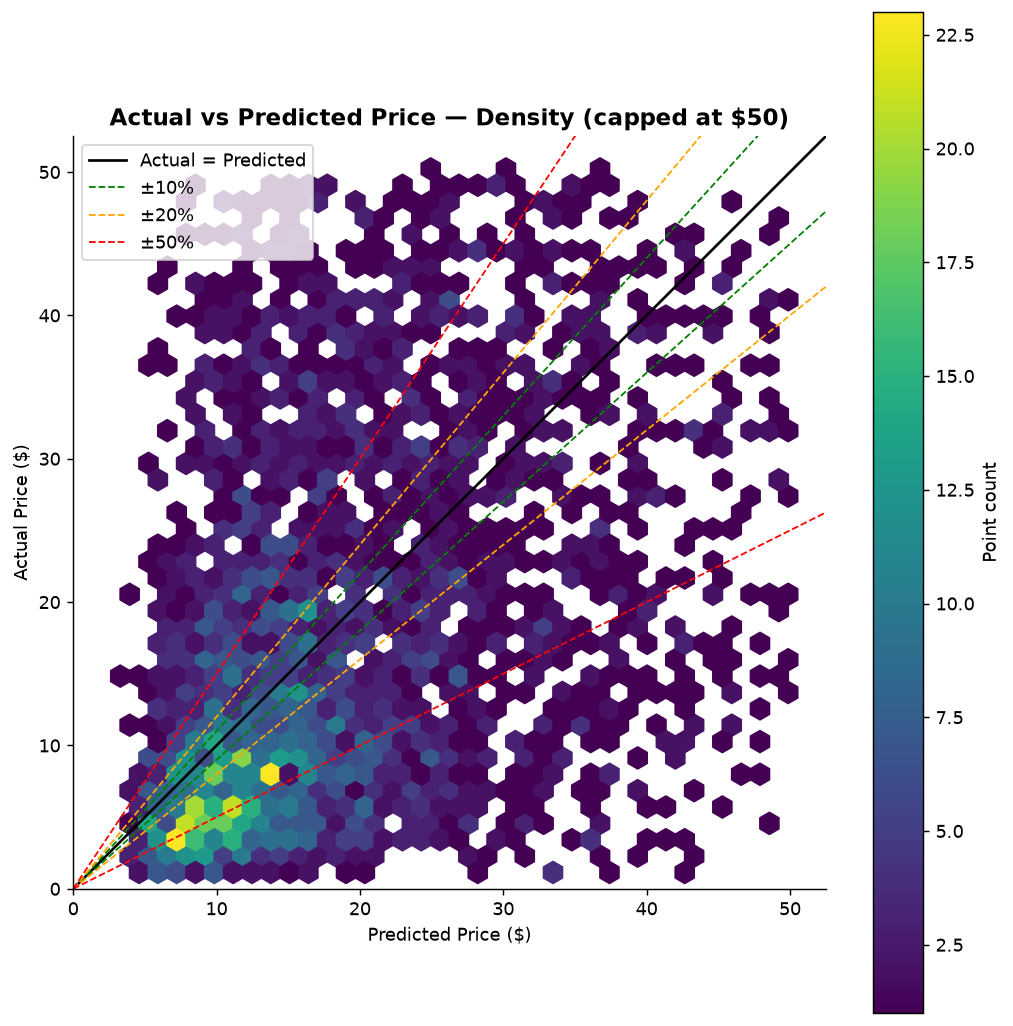

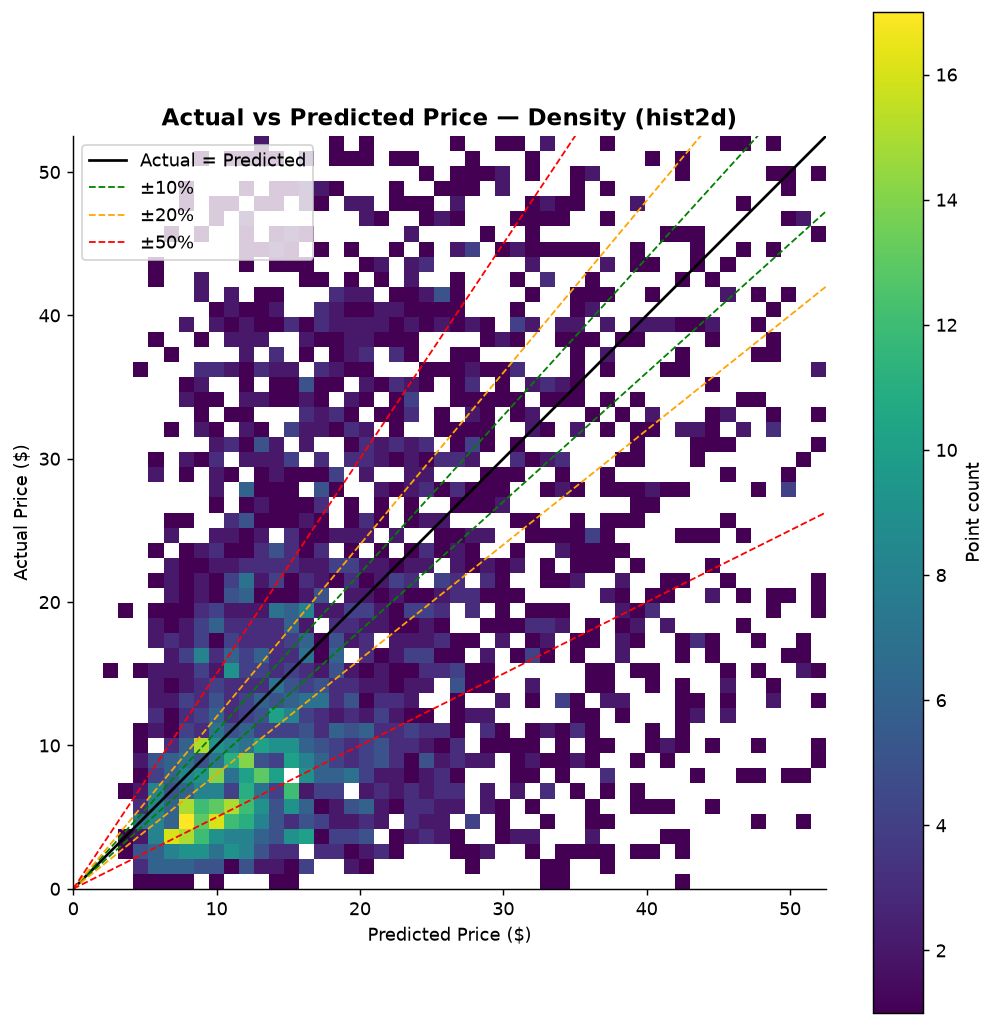

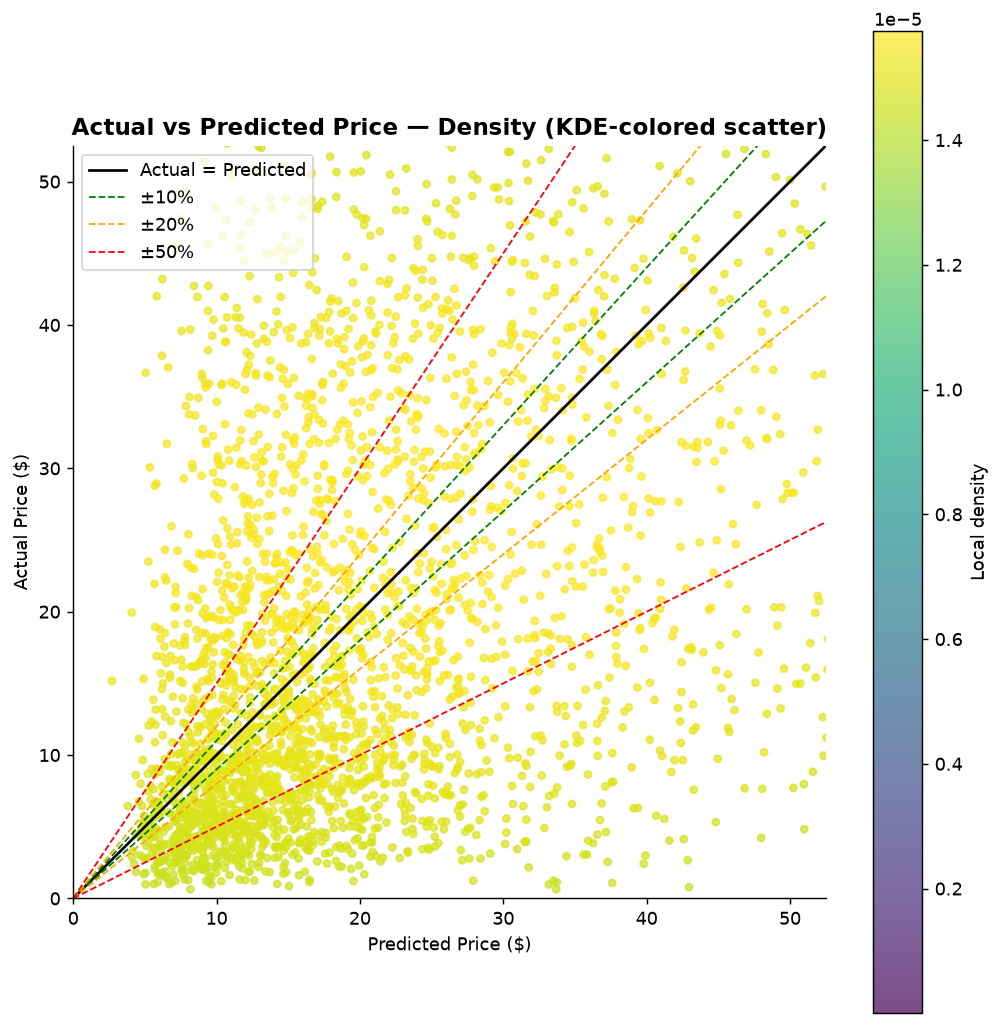

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Set your cap here
# ============================================================
MAX_PRICE = 50   # adjust this — try comparison['actual'].quantile(0.95) to auto-pick a reasonable cutoff

plot_data = comparison[
    (comparison['actual'] <= MAX_PRICE) &
    (comparison['predicted'] <= MAX_PRICE)
]

n_dropped = len(comparison) - len(plot_data)
print(f"Dropped {n_dropped} rows ({n_dropped/len(comparison):.1%}) above ${MAX_PRICE:,}")

lims = [0, MAX_PRICE * 1.05]
x_line = np.linspace(lims[0], lims[1], 200)

def draw_bands(ax):
    ax.plot(x_line, x_line, color='black', linewidth=1.5, label='Actual = Predicted')
    for pct, color in [(0.10, 'green'), (0.20, 'orange'), (0.50, 'red')]:
        ax.plot(x_line, x_line * (1 + pct), color=color, linestyle='--', linewidth=1,
                 label=f'±{int(pct*100)}%')
        ax.plot(x_line, x_line * (1 - pct), color=color, linestyle='--', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Predicted Price ($)')
    ax.set_ylabel('Actual Price ($)')
    ax.set_aspect('equal', adjustable='box')

# ------------------------------------------------------------
# hexbin, capped
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
hb = ax.hexbin(plot_data['predicted'], plot_data['actual'],
                gridsize=40, cmap='viridis', mincnt=1, extent=[*lims, *lims])
draw_bands(ax)
ax.set_title(f'Actual vs Predicted Price — Density (capped at ${MAX_PRICE:,})')
ax.legend(loc='upper left')
fig.colorbar(hb, ax=ax, label='Point count')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
h = ax.hist2d(comparison['predicted'], comparison['actual'],
              bins=50, cmap='viridis', cmin=1, range=[lims, lims])
draw_bands(ax)
ax.set_title('Actual vs Predicted Price — Density (hist2d)')
ax.legend(loc='upper left')
fig.colorbar(h[3], ax=ax, label='Point count')
plt.tight_layout()
plt.show()


xy = np.vstack([comparison['predicted'], comparison['actual']])
density = gaussian_kde(xy)(xy)
order = density.argsort()  # plot densest points last so they're on top

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(comparison['predicted'].values[order], comparison['actual'].values[order],
                 c=density[order], cmap='viridis', s=15, alpha=0.7)
draw_bands(ax)
ax.set_title('Actual vs Predicted Price — Density (KDE-colored scatter)')
ax.legend(loc='upper left')
fig.colorbar(sc, ax=ax, label='Local density')
plt.tight_layout()
plt.show()


In [ ]:
actual = comparison['actual']
pred = comparison['predicted']
residual = actual - pred

plt.figure(figsize=(9,6))

plt.scatter(
    pred,
    residual,
    alpha=.25,
    s=10
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.grid(alpha=.3)
plt.show()

In [ ]:
PCT_THRESHOLD = 0.20   # e.g. 20% below budget_min

threshold = df_raw['budget_min'] * (1 - PCT_THRESHOLD)
count = (df_raw['final_budget'] < threshold).sum()

print(f"Rows where final_budget < {PCT_THRESHOLD:.0%} below budget_min: "
      f"{count} ({count/len(df_raw):.2%} of {len(df_raw)} rows)")

Rows where final_budget < 20% below budget_min: 662 (3.37% of 19668 rows)


Clipped 887 rows (17.8%) beyond ±$100


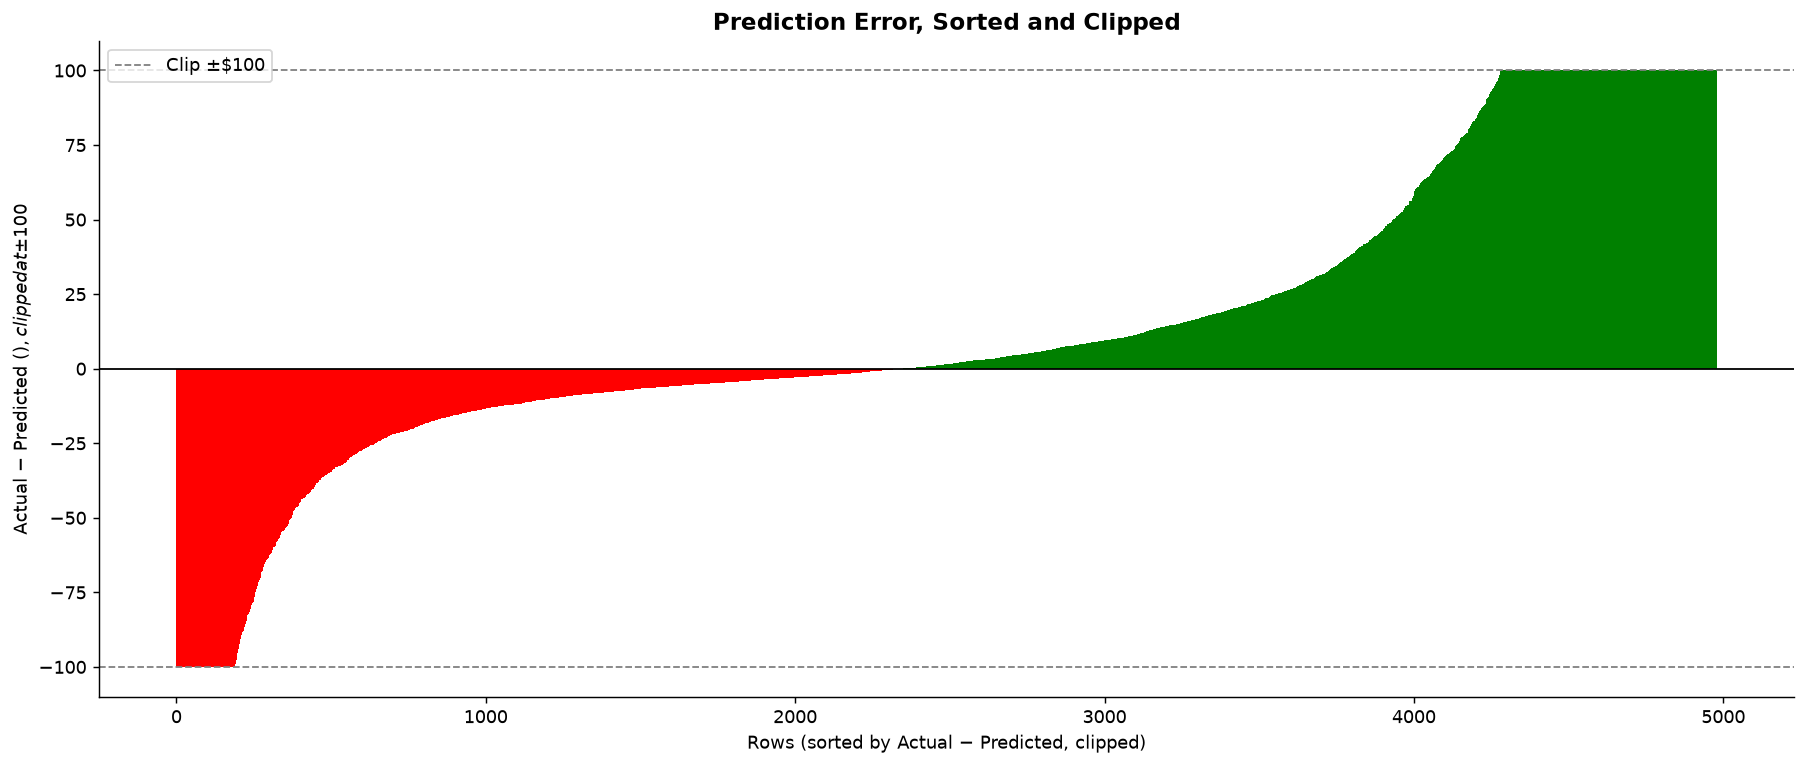

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Set your cap here — errors beyond this get clipped to the cap
# ============================================================
MAX_DIFF = 100   # adjust — try comparison['diff'].abs().quantile(0.95) to auto-pick

comparison['diff'] = comparison['actual'] - comparison['predicted']

# clip, don't drop — keeps every row, just caps the extreme values visually
comparison['diff_clipped'] = comparison['diff'].clip(-MAX_DIFF, MAX_DIFF)

n_clipped = (comparison['diff'].abs() > MAX_DIFF).sum()
print(f"Clipped {n_clipped} rows ({n_clipped/len(comparison):.1%}) beyond ±${MAX_DIFF:,}")

sorted_by_diff = comparison.sort_values('diff_clipped').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['red' if d < 0 else 'green' for d in sorted_by_diff['diff_clipped']]
ax.bar(sorted_by_diff.index, sorted_by_diff['diff_clipped'], color=colors, width=1.0)

# mark the clip boundaries so it's clear where clipping kicks in
ax.axhline(MAX_DIFF, color='gray', linestyle='--', linewidth=1, label=f'Clip ±${MAX_DIFF:,}')
ax.axhline(-MAX_DIFF, color='gray', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=1)

ax.set_xlabel('Rows (sorted by Actual − Predicted, clipped)')
ax.set_ylabel(f'Actual − Predicted ($), clipped at ±${MAX_DIFF:,}')
ax.set_title('Prediction Error, Sorted and Clipped')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 6 · Model comparison & residual plots (classical models)

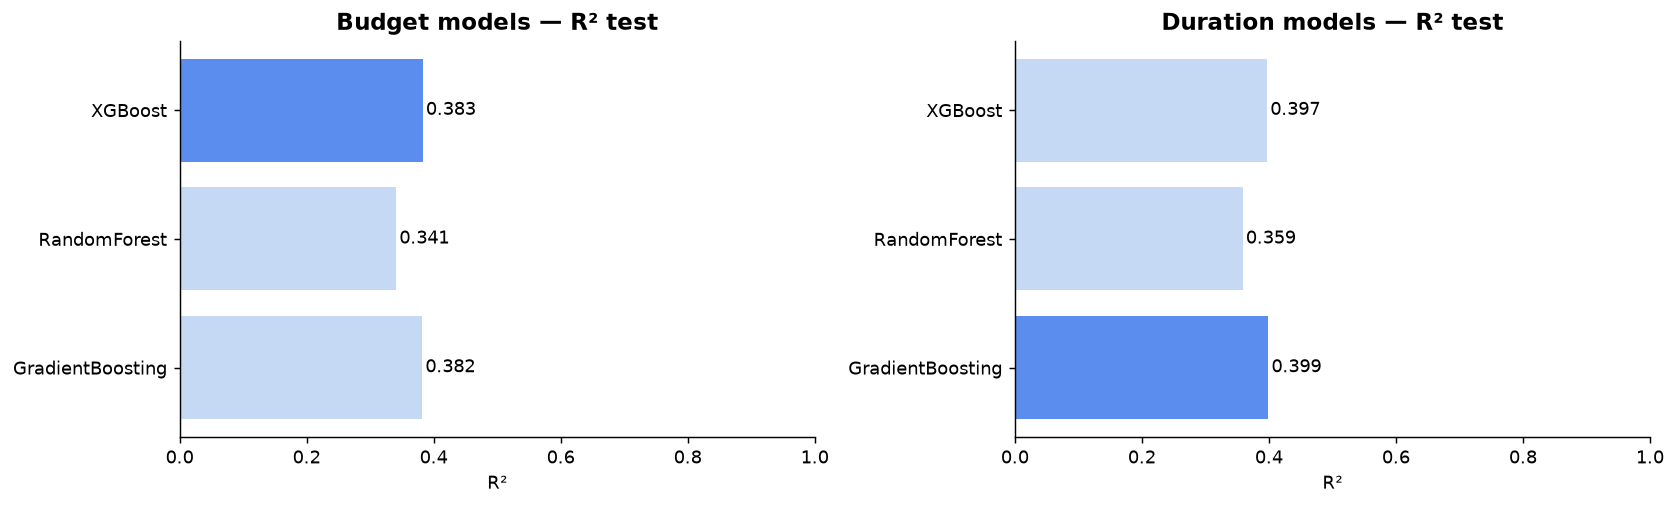

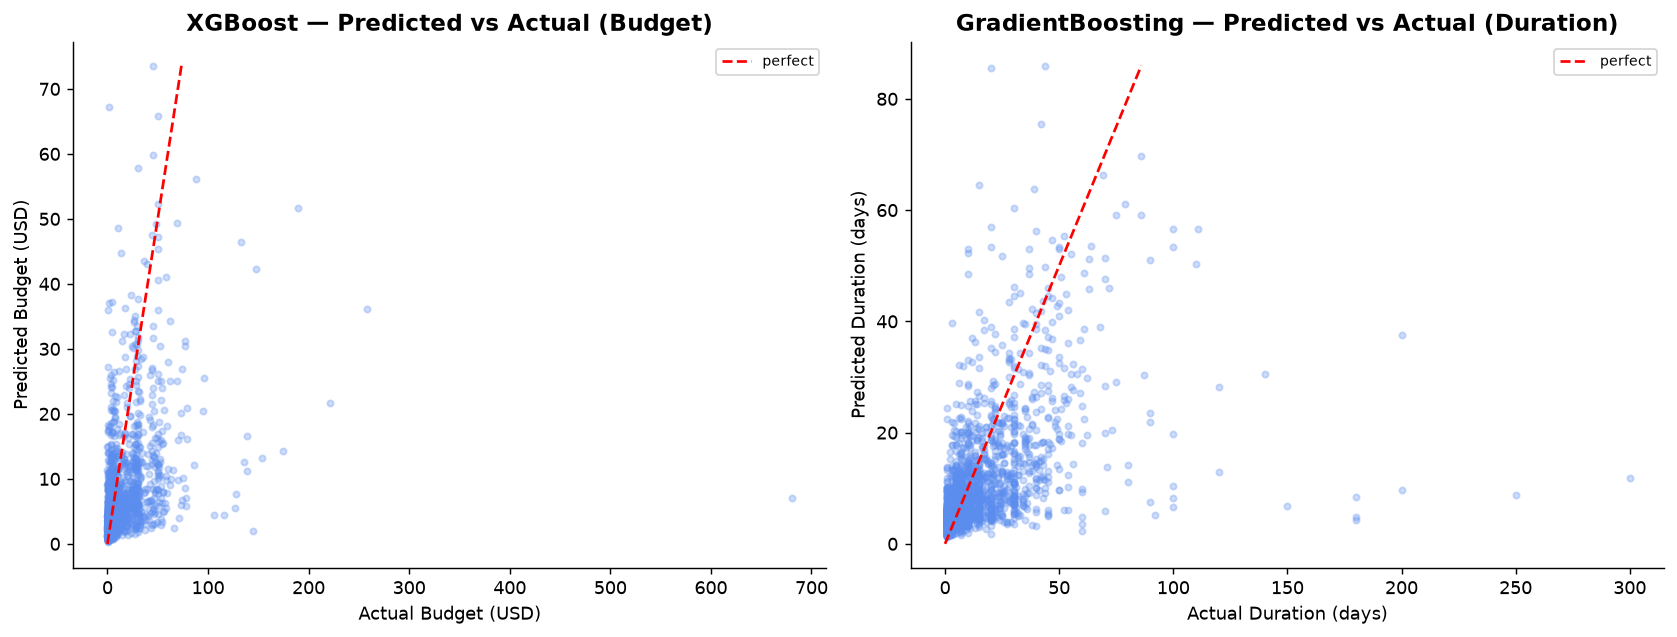

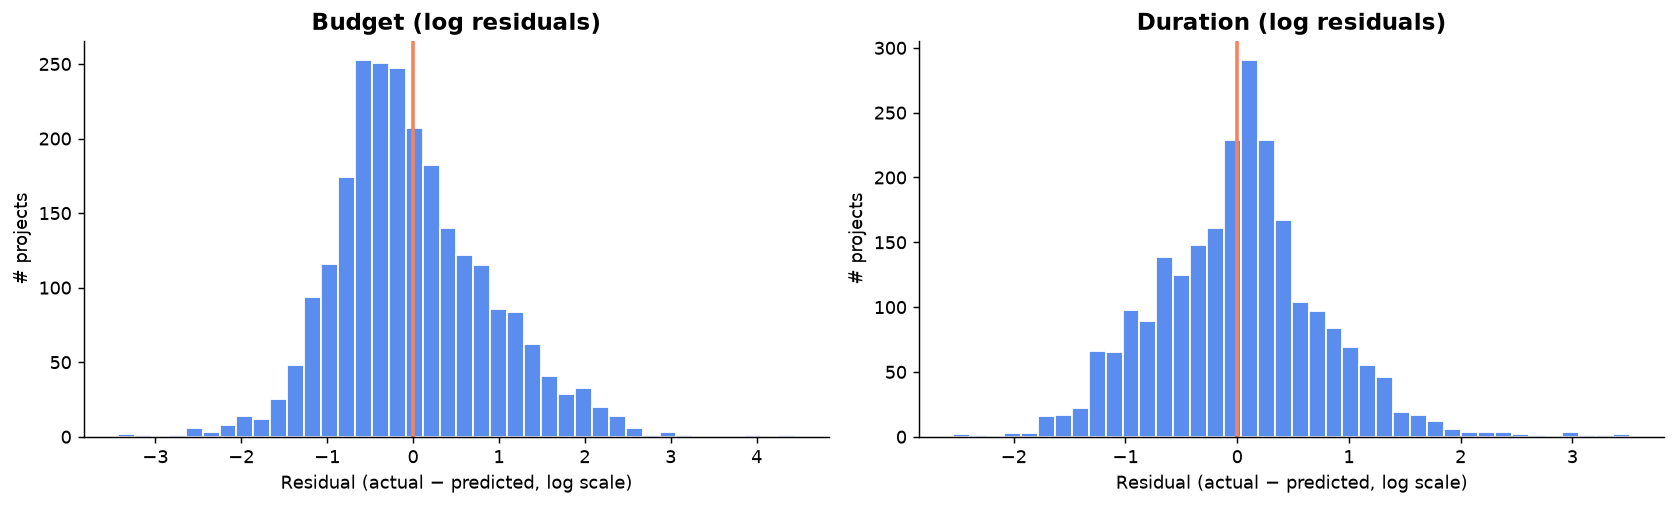

In [ ]:
# Side-by-side R² comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, results, title in [
    (axes[0], budget_results,   'Budget models — R² test'),
    (axes[1], duration_results, 'Duration models — R² test'),
]:
    names  = list(results.keys())
    r2s    = [results[n]['r2_test'] for n in names]
    colors = [ACCENT if r == max(r2s) else '#c5d9f5' for r in r2s]
    ax.barh(names, r2s, color=colors)
    for i, v in enumerate(r2s):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_xlabel('R²')
plt.tight_layout(); plt.show()

# Predicted vs actual for best budget model
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, res, label, unit in [
    (axes[0], best_budget,   'Budget', 'USD'),
    (axes[1], best_duration, 'Duration', 'days'),
]:
    y_true = np.expm1(yB_te if label=='Budget' else yD_te)
    y_pred = np.expm1(res['pred_test'])
    scale  = 1 if label == 'Budget' else 1  # already in USD, no scaling needed
    ax.scatter(y_true/scale, y_pred/scale, alpha=0.3, s=12, color=ACCENT)
    lim = max(y_true.quantile(0.97), y_pred.max()) / scale
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='perfect')
    ax.set_xlabel(f'Actual {label} ({unit})')
    ax.set_ylabel(f'Predicted {label} ({unit})')
    ax.set_title(f'{res["name"]} — Predicted vs Actual ({label})')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Residuals distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, res, y_te, label in [
    (axes[0], best_budget,   yB_te, 'Budget (log residuals)'),
    (axes[1], best_duration, yD_te, 'Duration (log residuals)'),
]:
    residuals = np.array(y_te) - res['pred_test']
    ax.hist(residuals, bins=40, color=ACCENT, edgecolor='white')
    ax.axvline(0, color=ACCENT2, linewidth=2)
    ax.set_title(label)
    ax.set_xlabel('Residual (actual − predicted, log scale)')
    ax.set_ylabel('# projects')
plt.tight_layout(); plt.show()

## 6b · Classical vs Deep Learning comparison
How does the best tree-based model stack up against the neural net?

  Target              Model  R2_test  MAE_test
  Budget            XGBoost 0.382694  7.854053
  Budget DeepLearning (MLP) 0.303992  8.116897
Duration   GradientBoosting 0.398919  7.755881
Duration DeepLearning (MLP) 0.328920  8.405992


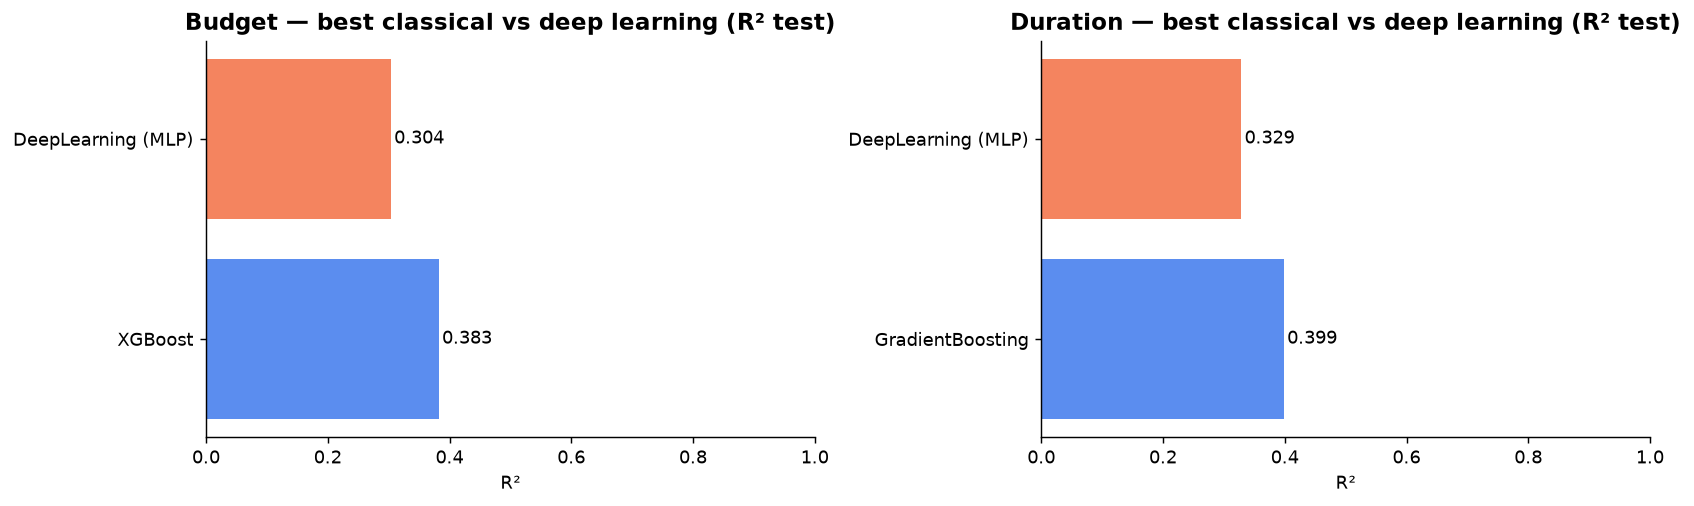


Budget: classical tree model wins on this dataset (classical R²=0.383 vs DL R²=0.304)
Duration: classical tree model wins on this dataset (classical R²=0.399 vs DL R²=0.329)

Note: tree ensembles (GBM/RF/XGBoost) often out-perform small MLPs on tabular
data like this, especially with a few thousand rows and mostly categorical /
count features — deep learning tends to need much more data (or embeddings for
high-cardinality categoricals) to pull ahead here.


In [ ]:
comparison_rows = [
    ('Budget',   best_budget_name,       best_budget['r2_test'],   best_budget['mae_test']),
    ('Budget',   'DeepLearning (MLP)',   dl_budget['r2_test'],     dl_budget['mae_test']),
    ('Duration', best_duration_name,     best_duration['r2_test'], best_duration['mae_test']),
    ('Duration', 'DeepLearning (MLP)',   dl_duration['r2_test'],   dl_duration['mae_test']),
]
comparison_df = pd.DataFrame(comparison_rows, columns=['Target', 'Model', 'R2_test', 'MAE_test'])
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, target in zip(axes, ['Budget', 'Duration']):
    sub = comparison_df[comparison_df['Target'] == target]
    colors = [ACCENT if 'Deep' not in m else ACCENT2 for m in sub['Model']]
    ax.barh(sub['Model'], sub['R2_test'], color=colors)
    for i, (v, m) in enumerate(zip(sub['R2_test'], sub['Model'])):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
    ax.set_title(f'{target} — best classical vs deep learning (R² test)')
    ax.set_xlim(0, 1)
    ax.set_xlabel('R²')
plt.tight_layout(); plt.show()

print()
for target, classical_r2, dl_r2 in [
    ('Budget',   best_budget['r2_test'],   dl_budget['r2_test']),
    ('Duration', best_duration['r2_test'], dl_duration['r2_test']),
]:
    winner = 'classical tree model' if classical_r2 >= dl_r2 else 'deep learning'
    print(f'{target}: {winner} wins on this dataset (classical R²={classical_r2:.3f} vs DL R²={dl_r2:.3f})')
print('\nNote: tree ensembles (GBM/RF/XGBoost) often out-perform small MLPs on tabular')
print('data like this, especially with a few thousand rows and mostly categorical /')
print('count features — deep learning tends to need much more data (or embeddings for')
print('high-cardinality categoricals) to pull ahead here.')


## 7 · Feature importance (global)

=== Budget model feature importance ===


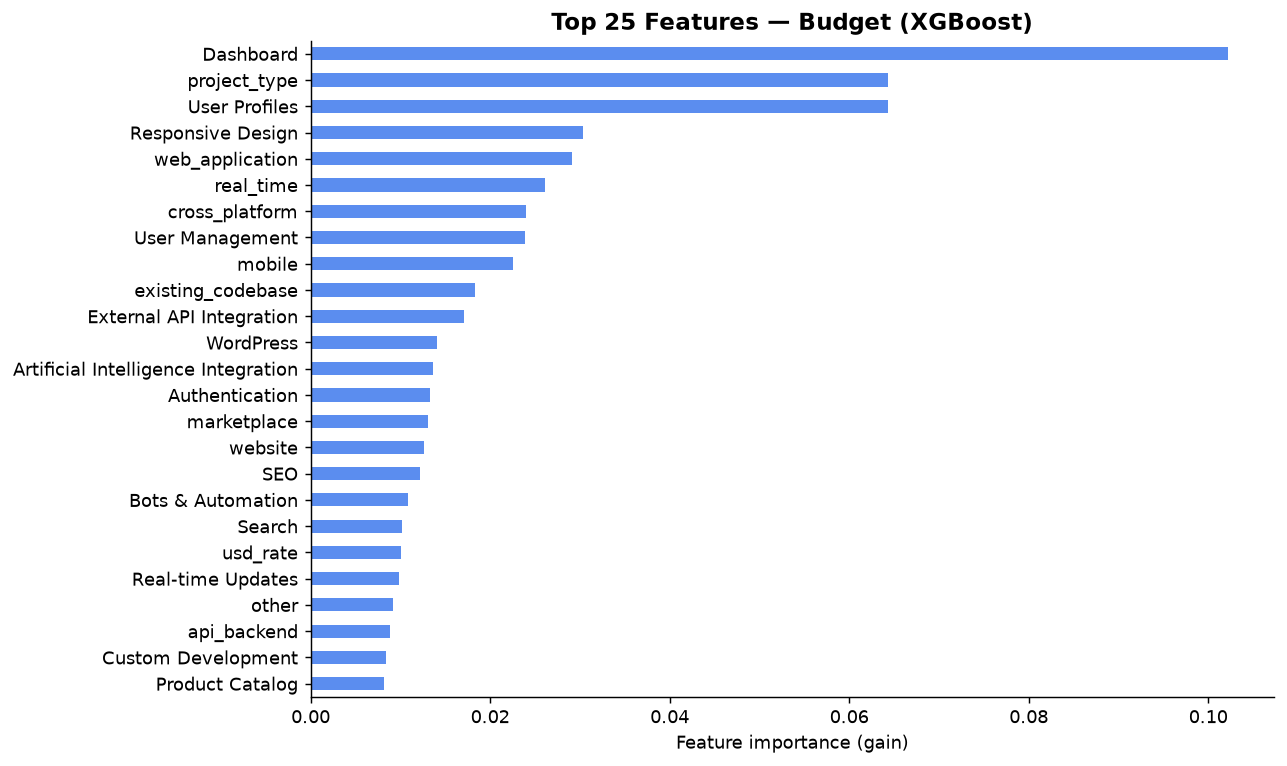

Dashboard            0.102212
project_type         0.064359
User Profiles        0.064306
Responsive Design    0.030355
web_application      0.029170
real_time            0.026123
cross_platform       0.024003
User Management      0.023840
mobile               0.022511
existing_codebase    0.018292

=== Duration model feature importance ===


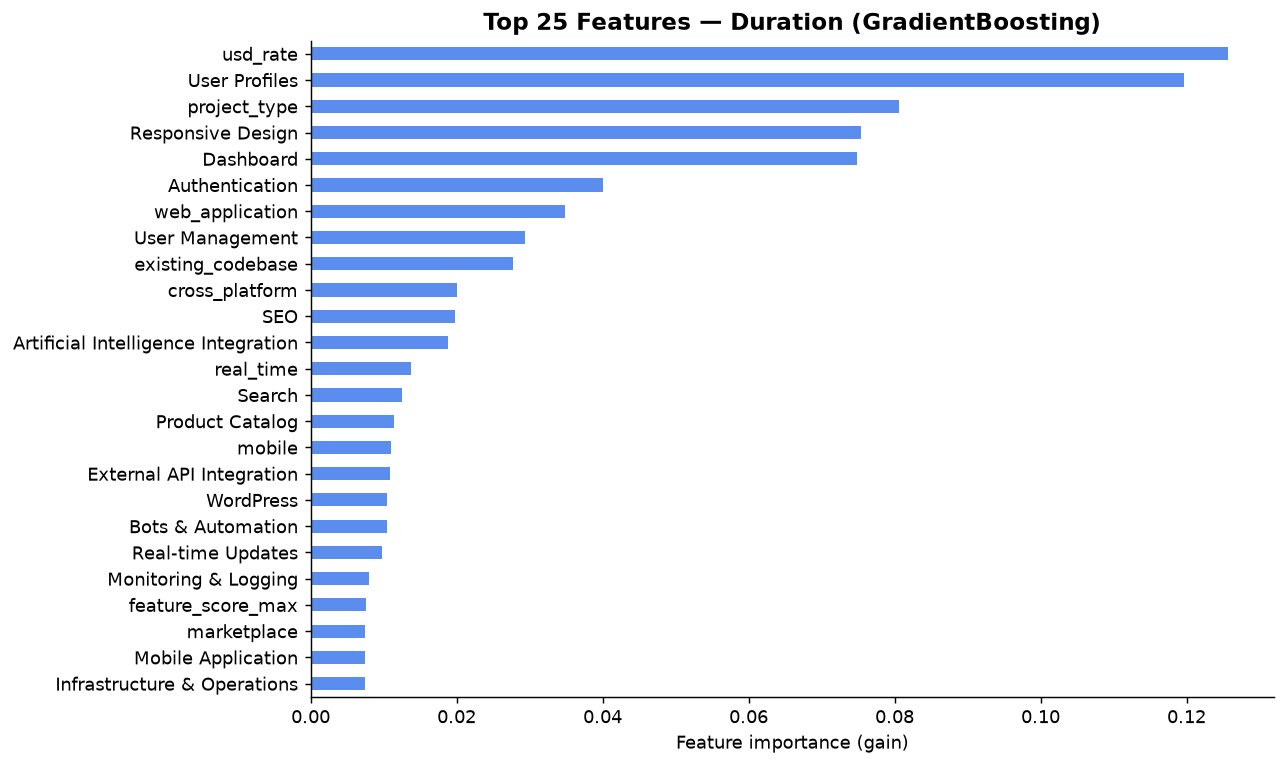

usd_rate             0.125695
User Profiles        0.119621
project_type         0.080589
Responsive Design    0.075390
Dashboard            0.074869
Authentication       0.040119
web_application      0.034864
User Management      0.029353
existing_codebase    0.027786
cross_platform       0.020056


In [ ]:
TOP_N = 25

def plot_importance(model, feature_names, title, top_n=TOP_N):
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names)
    else:
        return
    imp = imp.nlargest(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    imp[::-1].plot(kind='barh', ax=ax, color=ACCENT)
    ax.set_title(title)
    ax.set_xlabel('Feature importance (gain)')
    plt.tight_layout(); plt.show()
    return imp

print('=== Budget model feature importance ===')
imp_b = plot_importance(best_budget['model'], ALL_FEATURES, f'Top {TOP_N} Features — Budget ({best_budget_name})')
print(imp_b.head(10).to_string())

print('\n=== Duration model feature importance ===')
imp_d = plot_importance(best_duration['model'], ALL_FEATURES, f'Top {TOP_N} Features — Duration ({best_duration_name})')
print(imp_d.head(10).to_string())

## 8 · SHAP — per-prediction explanations
SHAP shows **why** the model made each prediction, not just which features matter on average.

Computing SHAP values for budget model...


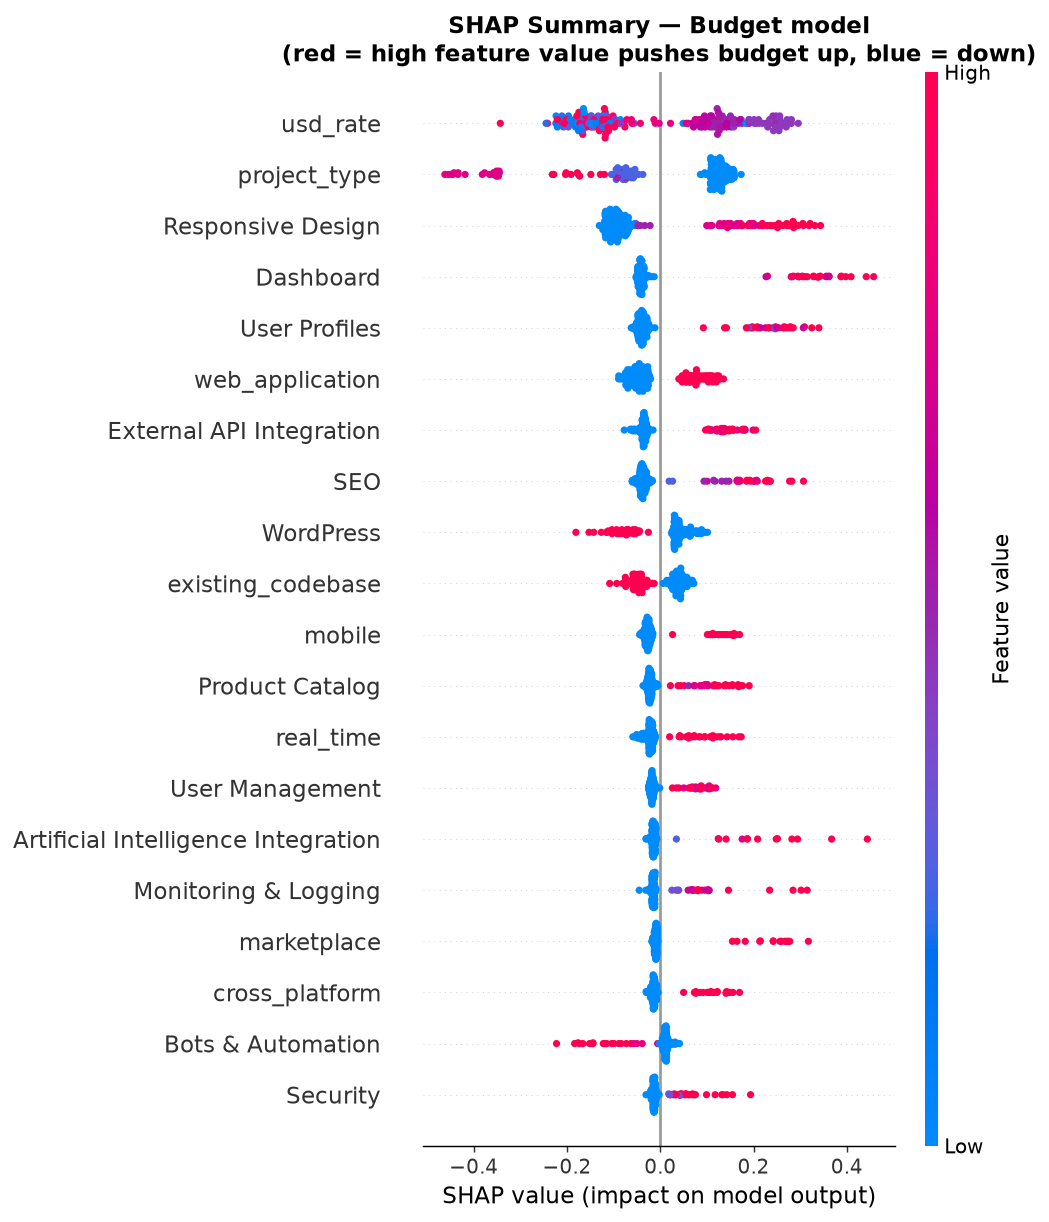

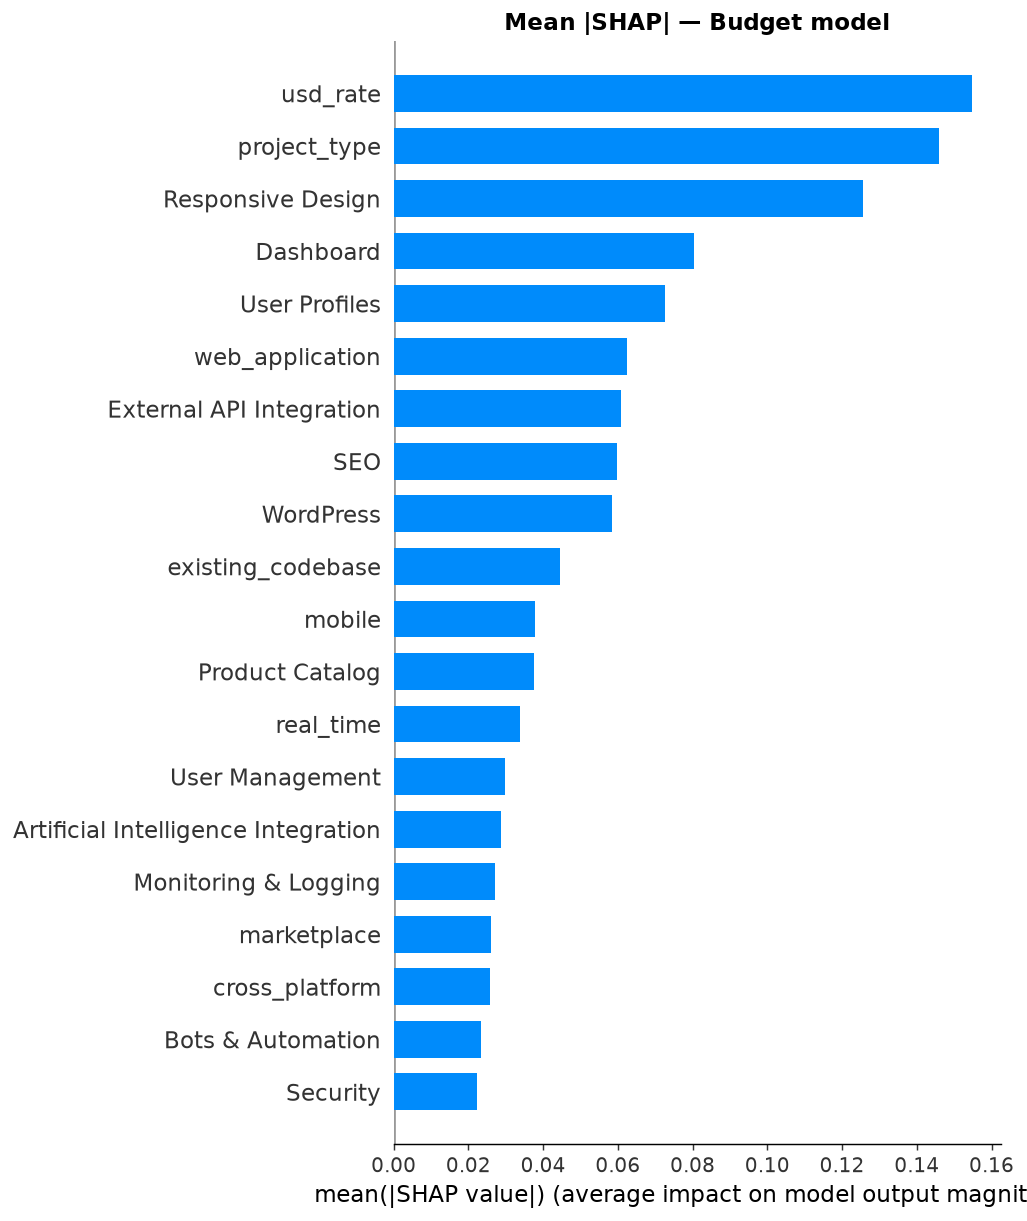


Explaining prediction for sample index 146 (predicted budget: 66)


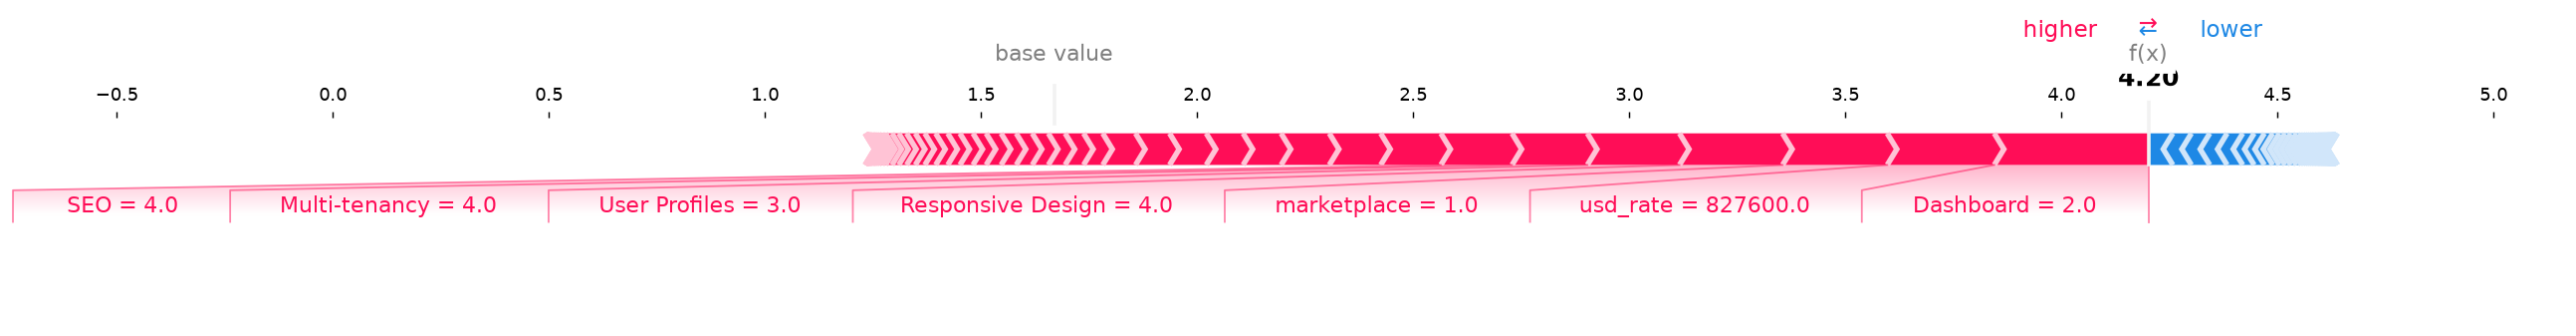

In [ ]:
# Use a subsample for speed (SHAP is O(n * features) per call)
SHAP_SAMPLE = min(200, len(X_te))
X_shap = X_te.sample(SHAP_SAMPLE, random_state=42)

print('Computing SHAP values for budget model...')
explainer_b = shap.TreeExplainer(best_budget['model'])
shap_vals_b = explainer_b.shap_values(X_shap)

# Summary plot — global view: which features drive predictions most?
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_vals_b, X_shap, feature_names=ALL_FEATURES,
                  max_display=20, show=False)
plt.title('SHAP Summary — Budget model\n(red = high feature value pushes budget up, blue = down)')
plt.tight_layout(); plt.show()

# Bar plot — mean |SHAP| per feature
shap.summary_plot(shap_vals_b, X_shap, feature_names=ALL_FEATURES,
                  plot_type='bar', max_display=20, show=False)
plt.title('Mean |SHAP| — Budget model')
plt.tight_layout(); plt.show()

# Single prediction explanation (most expensive predicted project)
idx = np.argmax(np.expm1(best_budget['model'].predict(X_shap)))
print(f'\nExplaining prediction for sample index {idx} '
      f'(predicted budget: {np.expm1(best_budget["model"].predict(X_shap.iloc[[idx]])[0]):,.0f})')
shap.force_plot(explainer_b.expected_value, shap_vals_b[idx], X_shap.iloc[idx],
                feature_names=ALL_FEATURES, matplotlib=True, show=False)
plt.tight_layout(); plt.show()

## 9 · Error analysis
Where does the model fail? Look at the worst predictions to spot patterns.

In [ ]:
test_idx = X_te.index
error_df = df.loc[test_idx, ['title','category','target_budget',
                               'feature_count','description_word_count']].copy()
error_df['pred_budget']   = np.expm1(best_budget['pred_test'])

error_df['budget_err_pct'] = (error_df['pred_budget'] - error_df['target_budget']).abs() / error_df['target_budget'] * 100
error_df['duration_err_pct'] = (error_df['pred_duration'] - error_df['target_duration']).abs() / error_df['target_duration'] * 100

# Error % distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, label in [
    (axes[0], 'budget_err_pct',   'Budget absolute error %'),
    (axes[1], 'duration_err_pct', 'Duration absolute error %'),
]:
    data = error_df[col].clip(upper=error_df[col].quantile(0.95))
    ax.hist(data, bins=30, color=ACCENT, edgecolor='white')
    ax.axvline(data.median(), color=ACCENT2, linewidth=2, label=f'median={data.median():.0f}%')
    ax.set_title(label)
    ax.set_xlabel('% error')
    ax.set_ylabel('# projects')
    ax.legend()
plt.tight_layout(); plt.show()

# Worst predictions
print('=== 10 worst budget predictions ===')
worst = error_df.nlargest(10, 'budget_err_pct')[[
    'title','category','target_budget','pred_budget','budget_err_pct','feature_count','description_word_count'
]]
worst['target_budget'] = worst['target_budget'].map(lambda x: f'${x:,.0f}')
worst['pred_budget']   = worst['pred_budget'].map(lambda x: f'${x:,.0f}')
worst['budget_err_pct'] = worst['budget_err_pct'].map(lambda x: f'{x:.0f}%')
print(worst.to_string(index=False))

# Error vs feature count scatter
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(error_df['feature_count'], error_df['budget_err_pct'].clip(upper=500),
           alpha=0.3, s=12, color=ACCENT)
ax.set_xlabel('Number of features tagged')
ax.set_ylabel('Budget error %')
ax.set_title('Does more features → lower error?')
plt.tight_layout(); plt.show()

ValueError: Length of values (3371) does not match length of index (5056)

## 10 · Cross-validation (more reliable than a single split)

In [ ]:
print('5-fold CV R² (budget) — this takes ~30s...')
cv_scores = cross_val_score(best_budget['model'], X, yB, cv=5, scoring='r2', n_jobs=-1)
print(f'  {best_budget_name}: {cv_scores.round(3)}  mean={cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

print('\n5-fold CV R² (duration)...')
cv_scores_d = cross_val_score(best_duration['model'], X, yD, cv=5, scoring='r2', n_jobs=-1)
print(f'  {best_duration_name}: {cv_scores_d.round(3)}  mean={cv_scores_d.mean():.3f} ± {cv_scores_d.std():.3f}')

5-fold CV R² (budget) — this takes ~30s...
  XGBoost: [-0.206  0.117  0.282  0.164  0.292]  mean=0.130 ± 0.181

5-fold CV R² (duration)...
  GradientBoosting: [-0.009  0.33   0.36   0.253 -1.873]  mean=-0.188 ± 0.853


## 11 · Inference helper
Predict budget and duration for a new project — fill in the dict with real values.

In [ ]:
def predict_project(feature_dict: dict) -> dict:
    """
    Pass a dict with the same keys as ALL_FEATURES.
    Missing keys default to 0. Enum values should be strings (e.g. 'medium').
    Returns {'budget': float, 'duration_days': float}.
    """
    row = pd.DataFrame([{f: feature_dict.get(f, 0) for f in ALL_FEATURES}])
    row[ENUM_COLS] = enc.transform(row[ENUM_COLS].astype(str))
    budget_log   = best_budget['model'].predict(row)[0]
    duration_log = best_duration['model'].predict(row)[0]
    return {
        'budget_usd':    int(np.expm1(budget_log)),
        'duration_days': round(np.expm1(duration_log), 1),
    }

# Example: a mid-complexity web app with payment processing
example = {
    'Payment Processing': 4,
    'Authentication': 4,
    'Dashboard': 3,
    'web_application': 1,
    'ecommerce': 1,
    'business_logic': 'medium',
    'ui_complexity': 'medium',
    'integration_complexity': 'medium',
    'algorithmic_complexity': 'low',
    'project_type': 'bugfix',
    'ai_level': 'none',
    'data_volume': 'small',
    'estimated_screens': 12,
    'estimated_entities': 6,
    'external_api_count': 2,
    'description_word_count': 80,
    'feature_count': 8,
    'web': 1,
}

result = predict_project(example)
print(f"Predicted budget:   \${result['budget_usd']:>12,.0f} USD")
print(f"Predicted duration: {result['duration_days']:>12.1f} days")

KeyError: "['ai_level', 'business_logic', 'data_volume', 'integration_complexity', 'ui_complexity', 'algorithmic_complexity'] not in index"